# Predicción de fallas en equipos industriales

## Proyecto de Aprendizaje de Máquina

**Dataset:** AI4I 2020 Predictive Maintenance Dataset

**Asignatura:** Aprendizaje de Máquina

**Integrantes:**
- Javiera Chávez
- Joaquín Olivares
- Claudio Yáñez

---

## Objetivo

En este proyecto queremos predecir si una máquina va a fallar o no, usando datos de sensores (temperatura, velocidad, torque, desgaste de la herramienta). Para eso analizamos los datos, los preparamos, entrenamos varios modelos y comparamos cuál funciona mejor. Al final usamos SHAP para ver qué variables influyen más en la predicción.

## 1. Importación de librerias.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Machine Learning Libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
import shap

## 2. Carga del dataset

Cargamos el dataset y revisamos que se haya leído bien: cuántas filas y columnas tiene, y cómo se ven los primeros registros.

In [3]:
# Cargar el dataset
from pathlib import Path
import os

def _find_project_root(marker="environment.yml"):
    p = Path.cwd().resolve()
    for candidate in [p, *p.parents]:
        if (candidate / marker).exists():
            return candidate
    raise FileNotFoundError(
        f"No se encontro '{marker}' en {p} ni en sus carpetas superiores. "
        "Ejecuta el notebook con el kernel del entorno 'ml' y no cambies el cwd manualmente."
    )

PROJECT_ROOT = _find_project_root()

# Por defecto usamos el dataset del repo, pero se puede probar otro dataset
# sin tocar el codigo, seteando la variable de entorno PERFECTIME_DATASET_PATH
# antes de abrir Jupyter (ej: export PERFECTIME_DATASET_PATH=/ruta/a/otro.csv)
DATASET_ENV_VAR = "PERFECTIME_DATASET_PATH"
ruta_personalizada = os.environ.get(DATASET_ENV_VAR)

if ruta_personalizada:
    DATA_PATH = Path(ruta_personalizada)
    print(f"Usando dataset externo definido en {DATASET_ENV_VAR}")
else:
    DATA_PATH = PROJECT_ROOT / "datasets" / "ai4i2020.csv"

df = pd.read_csv(DATA_PATH)
print(f"Dataset cargado desde: {DATA_PATH}")

# Mostrar dimensiones
print(f"Número de filas: {df.shape[0]}")
print(f"Número de columnas: {df.shape[1]}")

# Mostrar las primeras filas
display(df.head())

Dataset cargado desde: C:\Users\javic\Documents\Machine Learning\Proyecto\Sumativa 1\Proyecto sumativa 1\Proyecto Sumativa\datasets\ai4i2020.csv
Número de filas: 10000
Número de columnas: 14


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


## 3. Análisis exploratorio de datos

Antes de entrenar cualquier modelo hay que conocer los datos: qué tipo de variables hay, si están completos, cómo se distribuyen y si hay algo raro que pueda afectar a los modelos.

### 3.1 Información general

Revisamos cuántos registros y columnas tiene el dataset, y el tipo de dato de cada columna.

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  str    
 2   Type                     10000 non-null  str    
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9), str(2)
me

### 3.1.1 Descripción de las variables

Antes de mirar los números, dejamos claro qué mide cada columna del dataset, su tipo y su unidad. Esta tabla sirve de referencia para el resto del análisis.

In [5]:
# Descripción de cada variable del dataset AI4I 2020
descripcion_variables = pd.DataFrame([
    ("UDI", "Entero", "Identificador correlativo del registro. Se elimina antes de modelar."),
    ("Product ID", "Texto", "Identificador del producto (calidad + número de serie). Se elimina."),
    ("Type", "Categórica", "Calidad del producto: baja (L), media (M) o alta (H)."),
    ("Air temperature [K]", "Continua (K)", "Temperatura del aire en el entorno del proceso."),
    ("Process temperature [K]", "Continua (K)", "Temperatura del proceso."),
    ("Rotational speed [rpm]", "Entero (rpm)", "Velocidad de rotación de la herramienta."),
    ("Torque [Nm]", "Continua (Nm)", "Torque aplicado en el husillo."),
    ("Tool wear [min]", "Entero (min)", "Minutos de desgaste acumulado de la herramienta."),
    ("Machine failure", "Binaria (0/1)", "Variable objetivo: 1 si la máquina falló."),
    ("TWF", "Binaria (0/1)", "Falla por desgaste de herramienta. Se elimina (fuga de datos)."),
    ("HDF", "Binaria (0/1)", "Falla por disipación de calor. Se elimina (fuga de datos)."),
    ("PWF", "Binaria (0/1)", "Falla por potencia. Se elimina (fuga de datos)."),
    ("OSF", "Binaria (0/1)", "Falla por sobreesfuerzo. Se elimina (fuga de datos)."),
    ("RNF", "Binaria (0/1)", "Falla aleatoria. Se elimina (fuga de datos)."),
], columns=["Variable", "Tipo", "Descripción"])

# Rango observado (mín - máx para numéricas; categorías para el resto)
rangos = {}
for col in df.columns:
    if pd.api.types.is_numeric_dtype(df[col]):
        rangos[col] = f"{df[col].min()} - {df[col].max()}"
    elif df[col].nunique() <= 10:
        rangos[col] = ", ".join(map(str, sorted(df[col].unique())))
    else:
        rangos[col] = f"{df[col].nunique()} valores únicos"

descripcion_variables["Rango / categorías"] = descripcion_variables["Variable"].map(rangos)
display(descripcion_variables)

,Variable,Tipo,Descripción,Rango / categorías
0,UDI,Entero,Identificador correlativo del registro. Se eli...,1 - 10000
1,Product ID,Texto,Identificador del producto (calidad + número d...,10000 valores únicos
2,Type,Categórica,"Calidad del producto: baja (L), media (M) o al...","H, L, M"
3,Air temperature [K],Continua (K),Temperatura del aire en el entorno del proceso.,295.3 - 304.5
4,Process temperature [K],Continua (K),Temperatura del proceso.,305.7 - 313.8
5,Rotational speed [rpm],Entero (rpm),Velocidad de rotación de la herramienta.,1168 - 2886
6,Torque [Nm],Continua (Nm),Torque aplicado en el husillo.,3.8 - 76.6
7,Tool wear [min],Entero (min),Minutos de desgaste acumulado de la herramienta.,0 - 253
8,Machine failure,Binaria (0/1),Variable objetivo: 1 si la máquina falló.,0 - 1
9,TWF,Binaria (0/1),Falla por desgaste de herramienta. Se elimina ...,0 - 1


### 3.2 Estadísticas descriptivas

Calculamos el promedio, mínimo, máximo, etc. de las variables numéricas para tener una idea de sus valores típicos.

In [6]:
display(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
UDI,10000.0,5000.50000,2886.895680,1.0,2500.75,5000.5,7500.25,10000.0
Air temperature [K],10000.0,300.00493,2.000259,295.3,298.30,300.1,301.50,304.5
Process temperature [K],10000.0,310.00556,1.483734,305.7,308.80,310.1,311.10,313.8
Rotational speed [rpm],10000.0,1538.77610,179.284096,1168.0,1423.00,1503.0,1612.00,2886.0
Torque [Nm],10000.0,39.98691,9.968934,3.8,33.20,40.1,46.80,76.6
Tool wear [min],10000.0,107.95100,63.654147,0.0,53.00,108.0,162.00,253.0
Machine failure,10000.0,0.03390,0.180981,0.0,0.00,0.0,0.00,1.0
TWF,10000.0,0.00460,0.067671,0.0,0.00,0.0,0.00,1.0
HDF,10000.0,0.01150,0.106625,0.0,0.00,0.0,0.00,1.0
PWF,10000.0,0.00950,0.097009,0.0,0.00,0.0,0.00,1.0


**Qué vemos**

Las variables tienen escalas distintas: las temperaturas varían poco, mientras que la velocidad de rotación y el desgaste de la herramienta varían bastante más. La variable que queremos predecir (Machine failure) es binaria (0 o 1) y la mayoría de los registros son "sin falla".

### 3.3 Completitud de los datos

Revisamos si hay datos nulos o filas duplicadas.

In [7]:
# Valores nulos
nulls = pd.DataFrame({
    "Valores nulos": df.isnull().sum(),
    "Porcentaje (%)": (df.isnull().mean()*100).round(2)
})

display(nulls)

# Duplicados
print(f"Registros duplicados: {df.duplicated().sum()}")

,Valores nulos,Porcentaje (%)
UDI,0,0.0
Product ID,0,0.0
Type,0,0.0
Air temperature [K],0,0.0
Process temperature [K],0,0.0
Rotational speed [rpm],0,0.0
Torque [Nm],0,0.0
Tool wear [min],0,0.0
Machine failure,0,0.0
TWF,0,0.0


Registros duplicados: 0


### 3.4 Distribución de las variables

Hacemos histogramas de las variables numéricas para ver cómo se distribuyen los valores.

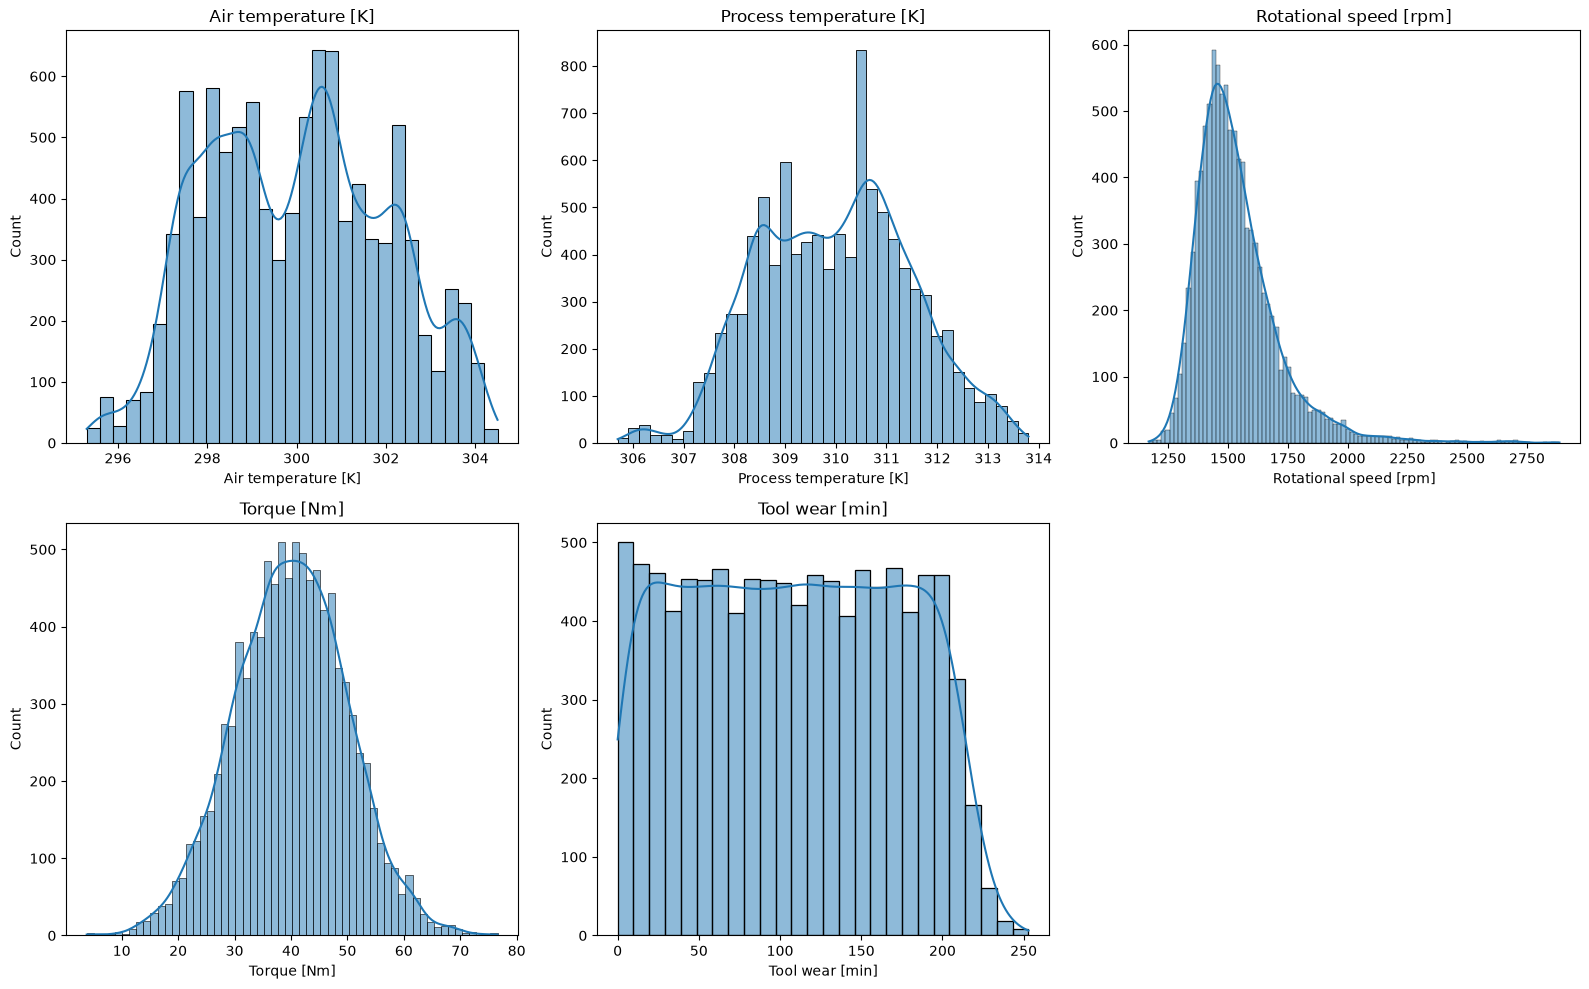

In [8]:
# Variables numéricas que serán analizadas mediante histogramas
variables_numericas = [
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]"
]

# Crear la figura donde se mostrarán los histogramas
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

# Generar un histograma para cada variable numérica
for i, columna in enumerate(variables_numericas):
    sns.histplot(data=df, x=columna, kde=True, ax=axes[i])
    axes[i].set_title(columna)

# Ocultar el último espacio vacío
axes[-1].axis("off")

# Ajustar el diseño y mostrar la figura
plt.tight_layout()
plt.show()

**Qué vemos**

Cada variable se distribuye distinto. La temperatura del aire y el torque se parecen a una distribución normal. La velocidad de rotación tiene más valores bajos que altos. El desgaste de herramienta está bastante parejo entre 0 y 253 minutos.

### 3.5 Valores atípicos (outliers)

Usamos boxplots para ver si hay valores muy alejados del resto en cada variable.

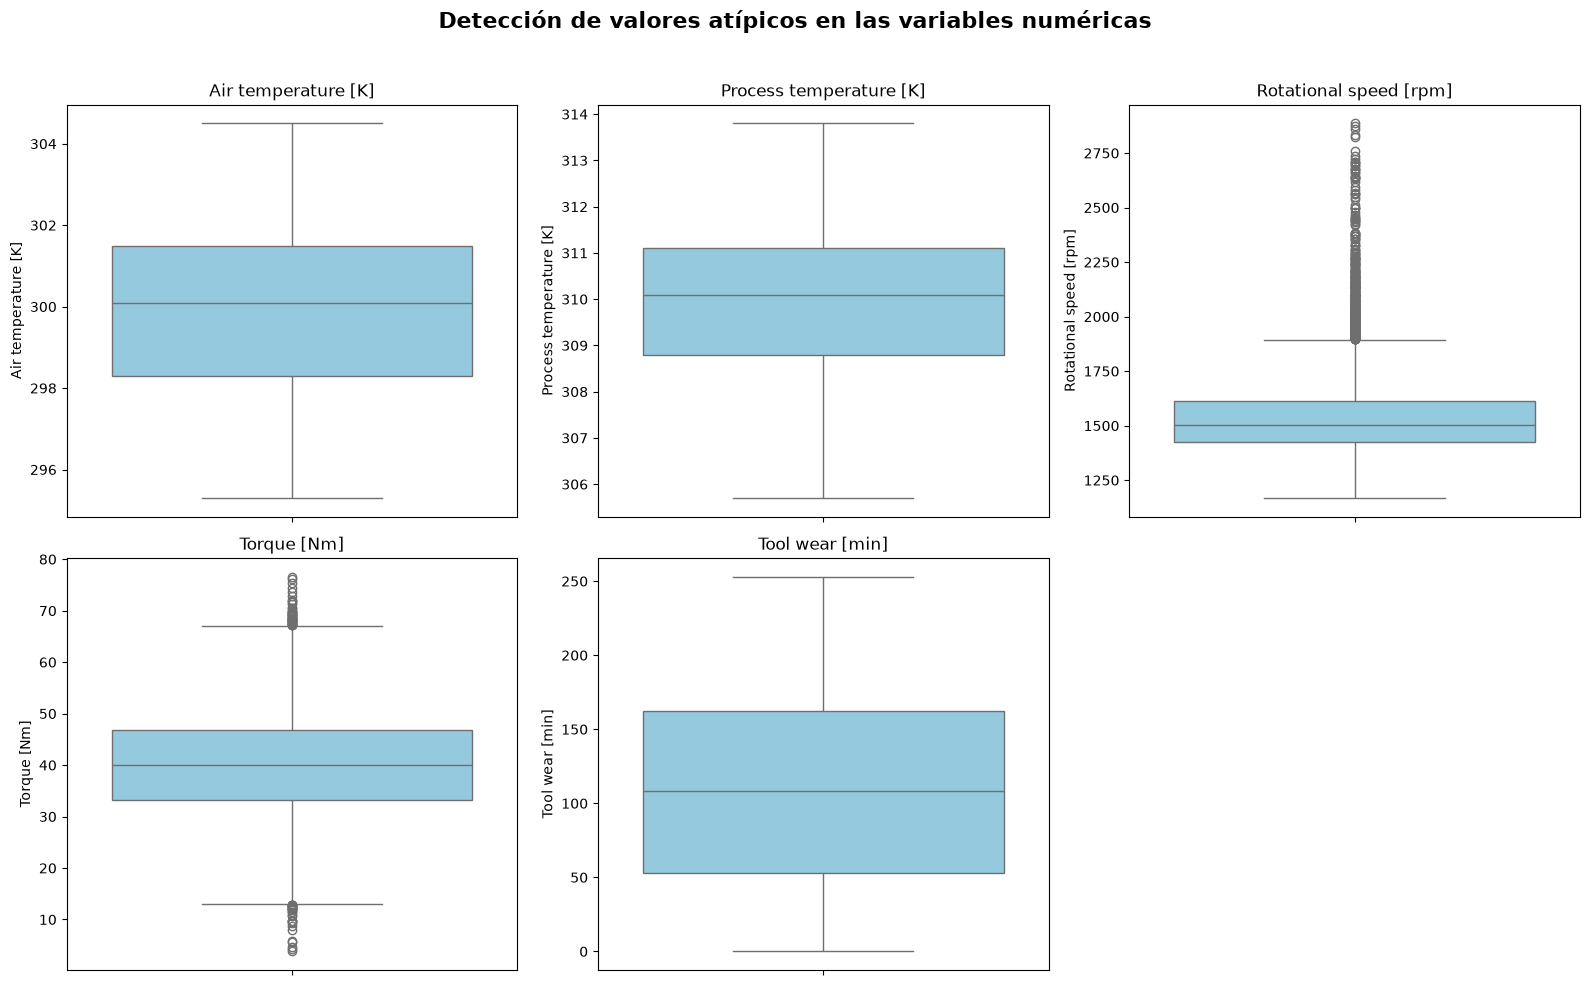

In [9]:
# Variables numéricas que serán evaluadas mediante diagramas de caja
variables_numericas = [
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]"
]

# Crear la figura donde se mostrarán los boxplots
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

# Generar un boxplot para cada variable numérica
for i, columna in enumerate(variables_numericas):

    sns.boxplot(
        data=df,
        y=columna,
        ax=axes[i],
        color="skyblue"
    )

    axes[i].set_title(columna)

# Ocultar el último espacio vacío
axes[-1].axis("off")

# Agregar un título general
plt.suptitle(
    "Detección de valores atípicos en las variables numéricas",
    fontsize=16,
    fontweight="bold"
)

# Ajustar el diseño de la figura
plt.tight_layout(rect=[0, 0, 1, 0.96])

# Mostrar los gráficos
plt.show()

**Qué vemos**

La temperatura del aire, la temperatura del proceso y el desgaste de herramienta no tienen outliers importantes. La velocidad de rotación y el torque sí tienen varios valores extremos.

No eliminamos esos valores: como el dataset es de mantenimiento predictivo, podrían ser justo los casos de máquinas a punto de fallar. Sacarlos nos haría perder información importante.

### 3.6 Correlación entre variables

Calculamos la correlación entre las variables numéricas para ver si están relacionadas entre sí.

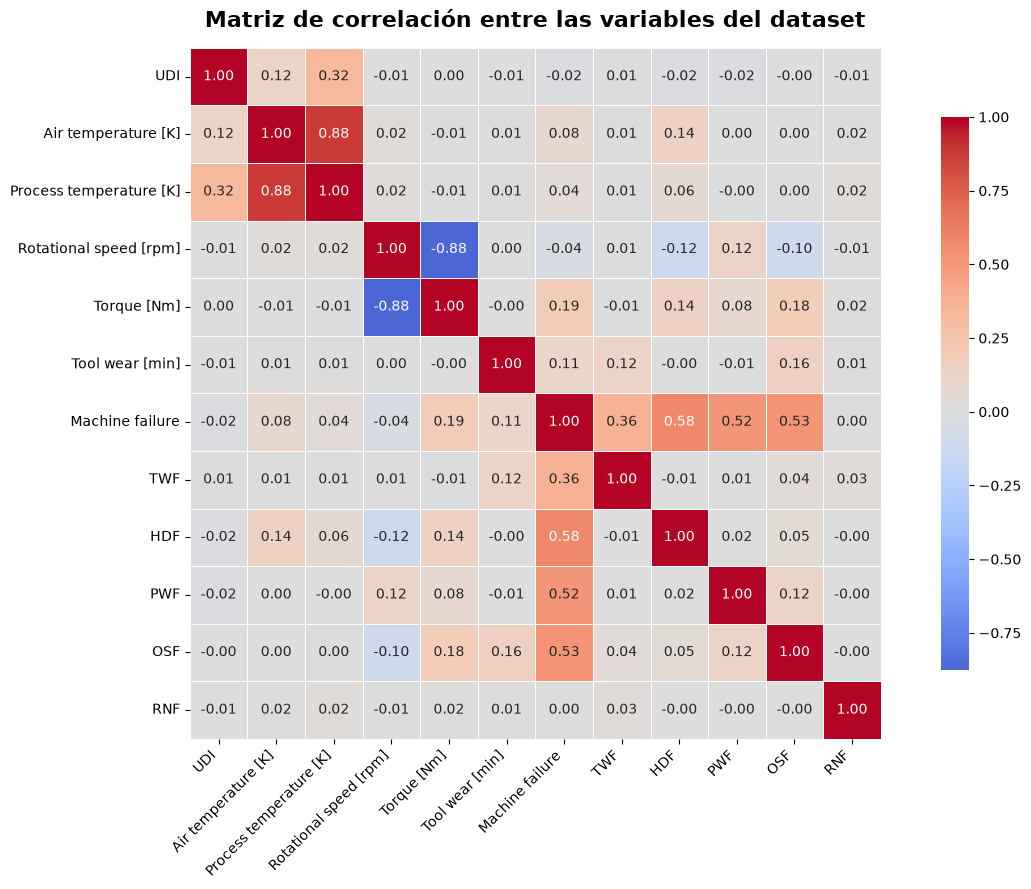

In [10]:
# MATRIZ DE CORRELACIÓN

# Se calcula la correlación de Pearson entre las variables
# numéricas para identificar relaciones lineales y posibles
# dependencias entre ellas.

# Calcular matriz de correlación
corr = df.corr(numeric_only=True)

# Crear figura
plt.figure(figsize=(13,9))

# Dibujar mapa de calor
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink":0.8}
)

# Título
plt.title(
    "Matriz de correlación entre las variables del dataset",
    fontsize=16,
    fontweight="bold",
    pad=15
)

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

**Qué vemos**

Hay correlación alta (0.88) entre la temperatura del aire y la del proceso: cuando una sube, la otra también.

También hay correlación negativa (-0.88) entre velocidad de rotación y torque: a mayor velocidad, menor torque.

Con la variable que queremos predecir (Machine failure) las correlaciones son bajas, salvo con Torque y Tool wear. Tiene sentido: una falla depende de varias variables juntas, no de una sola.

Las columnas TWF, HDF, PWF, OSF y RNF tienen correlación alta con Machine failure porque literalmente indican el tipo de falla que ocurrió. Por eso las vamos a sacar antes de entrenar los modelos — si las dejamos, el modelo estaría "haciendo trampa".

## 4. Calidad de los datos

Antes de entrenar los modelos revisamos que los datos estén completos, sean consistentes, no tengan errores, y vemos qué tan desbalanceadas están las clases.

### 4.1 Completitud

Revisamos si faltan datos o hay registros repetidos.

In [11]:
# EVALUACIÓN DE COMPLETITUD DEL DATASET

# Se verifica la existencia de valores nulos y registros
# duplicados para determinar si el conjunto de datos requiere
# tareas de imputación o eliminación de observaciones.

# Valores faltantes
print("Valores nulos por columna")
display(df.isnull().sum())

# Registros duplicados
duplicados = df.duplicated().sum()

print(f"\nRegistros duplicados: {duplicados}")

Valores nulos por columna


UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64


Registros duplicados: 0


**Qué vemos**

No hay valores nulos ni registros duplicados. No necesitamos rellenar ni eliminar nada.

### 4.2 Consistencia

Revisamos que cada variable tenga el tipo de dato correcto y que los valores tengan sentido.

In [12]:
# CONSISTENCIA DEL DATASET

# Se revisan los tipos de datos y los rangos mínimos y
# máximos de cada variable para verificar que los valores
# sean coherentes con el contexto del mantenimiento
# predictivo industrial.

# Tipos de datos
print("Tipos de datos")
display(df.dtypes)

# Rangos de las variables numéricas
rangos = pd.DataFrame({
    "Mínimo": df.min(numeric_only=True),
    "Máximo": df.max(numeric_only=True)
})

print("\nRangos de las variables numéricas")
display(rangos)

Tipos de datos


UDI                          int64
Product ID                     str
Type                           str
Air temperature [K]        float64
Process temperature [K]    float64
Rotational speed [rpm]       int64
Torque [Nm]                float64
Tool wear [min]              int64
Machine failure              int64
TWF                          int64
HDF                          int64
PWF                          int64
OSF                          int64
RNF                          int64
dtype: object


Rangos de las variables numéricas


,Mínimo,Máximo
UDI,1.0,10000.0
Air temperature [K],295.3,304.5
Process temperature [K],305.7,313.8
Rotational speed [rpm],1168.0,2886.0
Torque [Nm],3.8,76.6
Tool wear [min],0.0,253.0
Machine failure,0.0,1.0
TWF,0.0,1.0
HDF,0.0,1.0
PWF,0.0,1.0


**Qué vemos**

Los tipos de dato son los esperados: las temperaturas y el torque son decimales, la velocidad y el desgaste son enteros, y Type/Product ID son texto. Los rangos también tienen sentido físico. Las variables binarias (Machine failure, TWF, etc.) solo tienen 0 y 1. Los datos están consistentes.

### 4.3 Exactitud

Revisamos que no haya valores imposibles, como negativos donde no deberían existir.

In [13]:
# EXACTITUD DEL DATASET

# Se verifica que las variables numéricas no presenten
# valores negativos y que la variable categórica "Type"
# contenga únicamente las categorías esperadas.

print("Verificación de valores negativos")

print(f"Air temperature [K]: {(df['Air temperature [K]'] < 0).sum()}")
print(f"Process temperature [K]: {(df['Process temperature [K]'] < 0).sum()}")
print(f"Rotational speed [rpm]: {(df['Rotational speed [rpm]'] < 0).sum()}")
print(f"Torque [Nm]: {(df['Torque [Nm]'] < 0).sum()}")
print(f"Tool wear [min]: {(df['Tool wear [min]'] < 0).sum()}")

print("\nCategorías presentes en la variable Type")

display(pd.DataFrame({
    "Categoría": sorted(df["Type"].unique())
}))

Verificación de valores negativos
Air temperature [K]: 0
Process temperature [K]: 0
Rotational speed [rpm]: 0
Torque [Nm]: 0
Tool wear [min]: 0

Categorías presentes en la variable Type


,Categoría
0,H
1,L
2,M


**Qué vemos**

Ninguna variable numérica tiene valores negativos, lo cual tiene sentido porque son medidas físicas. La variable Type solo tiene las categorías esperadas (H, L, M). No hay errores evidentes en los datos.

### 4.4 Balance de clases

Revisamos cuántos registros hay de cada clase en la variable que queremos predecir.

,Cantidad,Porcentaje (%)
Sin falla,9661,96.61
Con falla,339,3.39


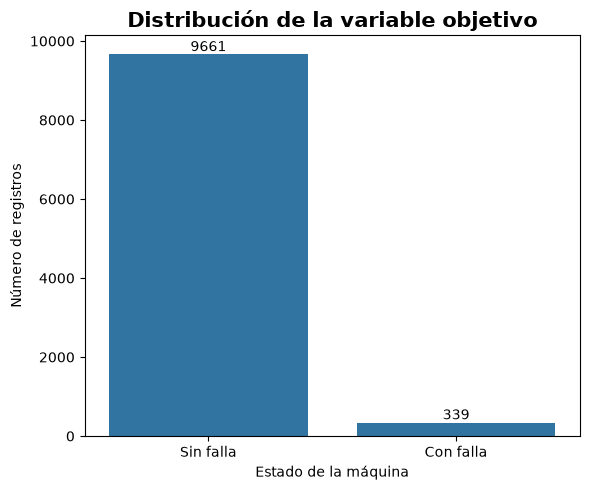

In [14]:
# BALANCE DE CLASES

# Se analiza la distribución de la variable objetivo
# "Machine failure" para determinar si existe desbalance
# entre las clases antes del entrenamiento de los modelos.

# Frecuencia absoluta
conteo = df["Machine failure"].value_counts().sort_index()

# Frecuencia porcentual
porcentaje = (conteo / len(df) * 100).round(2)

# Crear tabla resumen
balance = pd.DataFrame({
    "Cantidad": conteo.values,
    "Porcentaje (%)": (conteo/len(df)*100).round(2).values
},
index=["Sin falla", "Con falla"])

display(balance)

# Gráfico de distribución de clases

plt.figure(figsize=(6,5))

ax = sns.countplot(
    x=df["Machine failure"].map({
        0: "Sin falla",
        1: "Con falla"
    })
)

plt.xlabel("")

plt.title(
    "Distribución de la variable objetivo",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Estado de la máquina")
plt.ylabel("Número de registros")

# Mostrar cantidad sobre cada barra
for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

**Qué vemos**

Hay un desbalance grande: de 10.000 registros, 9.661 (96,61%) son "sin falla" y solo 339 (3,39%) son "con falla".

Esto es un problema porque un modelo entrenado así podría simplemente predecir siempre "sin falla" y aun así tener un accuracy alto, sin aprender de verdad a detectar fallas. Por eso más adelante usamos SMOTE para balancear las clases.

## 5. Preprocesamiento de los datos

Antes de entrenar los modelos dejamos los datos en un formato que los algoritmos puedan usar: sacamos columnas que no sirven, pasamos las categorías a números, y separamos lo que el modelo usa para predecir de lo que queremos predecir.

### 5.1 Eliminar columnas que no sirven

Sacamos UDI y Product ID porque son solo identificadores, no dicen nada sobre si la máquina va a fallar.

También sacamos TWF, HDF, PWF, OSF y RNF porque indican el tipo específico de falla que ocurrió. Esa información no existiría antes de que la falla pase, así que dejarla sería fuga de datos (data leakage).

In [15]:
# Se eliminan las columnas que no aportan información útil
# para el entrenamiento del modelo.

# UDI y Product ID corresponden únicamente a identificadores.
# TWF, HDF, PWF, OSF y RNF representan tipos específicos de
# fallas y su uso provocaría fuga de información (Data Leakage).

columnas_a_eliminar = [
    'UDI',
    'Product ID',
    'TWF',
    'HDF',
    'PWF',
    'OSF',
    'RNF'
]

df_clean = df.drop(columns=columnas_a_eliminar)

# Verificar las columnas restantes
print("Columnas del dataset después del preprocesamiento:")
display(pd.DataFrame(df_clean.columns, columns=["Columnas conservadas"]))


Columnas del dataset después del preprocesamiento:


,Columnas conservadas
0,Type
1,Air temperature [K]
2,Process temperature [K]
3,Rotational speed [rpm]
4,Torque [Nm]
5,Tool wear [min]
6,Machine failure


**Qué vemos**

Después de sacar esas columnas quedan 7 variables: 6 para predecir (Type, temperaturas, velocidad, torque, desgaste) y 1 que es lo que queremos predecir (Machine failure).

### 5.2 Normalizar nombres de columnas

Cambiamos los espacios por guiones bajos y sacamos los corchetes de los nombres de columna, para que sea más fácil trabajar con ellas en el código.

In [16]:
# Normalización de nombres de columnas

# Se reemplazan espacios y caracteres especiales para
# mejorar la compatibilidad con algunos algoritmos.

df_clean.columns = [
    c.replace(" ", "_")
     .replace("[", "")
     .replace("]", "")
    for c in df_clean.columns
]

# Verificar los nuevos nombres
print("Nombres de columnas normalizados:")
display(pd.DataFrame(df_clean.columns, columns=["Columnas"]))

Nombres de columnas normalizados:


,Columnas
0,Type
1,Air_temperature_K
2,Process_temperature_K
3,Rotational_speed_rpm
4,Torque_Nm
5,Tool_wear_min
6,Machine_failure


**Qué vemos**

Los nombres quedaron más simples (ej. "Air temperature [K]" pasó a "Air_temperature_K"). Esto no cambia los datos, solo cómo los llamamos en el código.

### 5.3 Codificar la variable categórica

Type tiene texto (L, M, H) y los modelos necesitan números. Usamos One-Hot Encoding, que convierte cada categoría en una columna de 0 y 1.

In [17]:
# 5.3 Codificación de variables categóricas

# La variable "Type" se transforma mediante One-Hot Encoding
# para convertir sus categorías en variables numéricas.

df_clean = pd.get_dummies(
    df_clean,
    columns=["Type"],
    drop_first=True
)

# Verificar el resultado de la codificación
print("Columnas después de la codificación:")

display(pd.DataFrame(df_clean.columns, columns=["Columnas"]))

Columnas después de la codificación:


,Columnas
0,Air_temperature_K
1,Process_temperature_K
2,Rotational_speed_rpm
3,Torque_Nm
4,Tool_wear_min
5,Machine_failure
6,Type_L
7,Type_M


**Qué vemos**

Se crearon las columnas Type_L y Type_M. La categoría H no necesita columna propia: si ambas son 0, el modelo entiende que es H.

### 5.4 Separar variables predictoras y variable objetivo

Separamos las columnas que el modelo usa para predecir (X) de la columna que queremos predecir (y).

In [18]:
# Separación de variables predictoras y variable objetivo

# Se separan las características utilizadas para entrenar
# los modelos (X) y la variable objetivo (y).

X = df_clean.drop("Machine_failure", axis=1)
y = df_clean["Machine_failure"]

# Verificar dimensiones
print(f"Número de variables predictoras: {X.shape[1]}")
print(f"Número de registros: {X.shape[0]}")

print("\nVariable objetivo:")
display(y.value_counts().to_frame(name="Cantidad"))

Número de variables predictoras: 7
Número de registros: 10000

Variable objetivo:


,Cantidad
Machine_failure,
0,9661
1,339


**Qué vemos**

Quedaron 7 variables predictoras (X) y 10.000 registros. La variable objetivo (y) sigue mostrando el mismo desbalance: 9.661 sin falla y 339 con falla.

## 6. Preparar los datos para entrenar

Dividimos los datos en entrenamiento y prueba, escalamos las variables numéricas, y balanceamos las clases con SMOTE.

### 6.1 Dividir en entrenamiento, validación y prueba

Separamos los datos en tres conjuntos: 70% para entrenamiento, 15% para validación y 15% para prueba, utilizando stratify para conservar la proporción de fallas en cada conjunto.

In [40]:
# División del dataset en entrenamiento, validación y prueba
#
# Se divide el dataset en:
# - 70% entrenamiento
# - 15% validación
# - 15% prueba
# conservando la proporción de la variable objetivo mediante stratify.

# Primera división: 70% entrenamiento y 30% temporal
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

# Segunda división: del 30% temporal se obtiene 15% validación
# y 15% prueba.
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

# Mostrar dimensiones de cada conjunto
print("Conjunto de entrenamiento")
print(f"Registros: {X_train.shape[0]}")
print(f"Variables: {X_train.shape[1]}")

print("\nConjunto de validación")
print(f"Registros: {X_val.shape[0]}")
print(f"Variables: {X_val.shape[1]}")

print("\nConjunto de prueba")
print(f"Registros: {X_test.shape[0]}")
print(f"Variables: {X_test.shape[1]}")

Conjunto de entrenamiento
Registros: 7000
Variables: 7

Conjunto de validación
Registros: 1500
Variables: 7

Conjunto de prueba
Registros: 1500
Variables: 7


**Qué vemos**

Quedaron 7.000 registros para entrenamiento, 1.500 para validación y 1.500 para prueba, manteniendo los 7 predictores utilizados en el modelo. Gracias a stratify, la proporción de fallas se mantiene de forma similar en los tres conjuntos.

### 6.2 Escalar las variables

Las variables tienen escalas muy distintas (por ejemplo, la velocidad de rotación se mide en miles y el torque en decenas). Usamos StandardScaler para llevar las variables a una escala comparable.

El escalador se ajusta únicamente con los datos de entrenamiento y luego se aplica sin volver a ajustarlo sobre los conjuntos de validación y prueba, evitando incorporar información de estos conjuntos durante el procesamiento.

In [41]:
# 6.2 Escalado de variables

# Se estandarizan las variables numéricas utilizando StandardScaler
# para llevarlas a una escala comparable.

scaler = StandardScaler()

# Ajustar el escalador únicamente con el conjunto de entrenamiento
X_train_scaled = scaler.fit_transform(X_train)

# Aplicar la misma transformación al conjunto de validación y prueba
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# Convertir nuevamente a DataFrame para conservar los nombres de las columnas
X_train_scaled = pd.DataFrame(
    X_train_scaled,
    columns=X_train.columns
)

X_val_scaled = pd.DataFrame(
    X_val_scaled,
    columns=X_val.columns
)

X_test_scaled = pd.DataFrame(
    X_test_scaled,
    columns=X_test.columns
)

# Mostrar una vista preliminar del conjunto escalado
print("Primeros registros del conjunto de entrenamiento escalado:")
display(X_train_scaled.head())

Primeros registros del conjunto de entrenamiento escalado:


,Air_temperature_K,Process_temperature_K,Rotational_speed_rpm,Torque_Nm,Tool_wear_min,Type_L,Type_M
0,-1.105779,-1.759415,2.012835,-1.569298,0.334742,-1.230964,1.539033
1,1.840492,1.547973,-1.055557,1.099287,-0.041084,0.812372,-0.649758
2,-1.405400,-1.421926,-0.256554,-0.160045,0.600952,0.812372,-0.649758
3,1.790556,1.547973,0.503608,-0.759727,1.806727,-1.230964,1.539033
4,0.442262,1.277982,3.333409,-2.348885,-1.011967,-1.230964,-0.649758


**Qué vemos**

Las variables quedaron estandarizadas, con valores centrados en torno a 0 y una desviación estándar cercana a 1. El mismo escalador ajustado con el conjunto de entrenamiento se aplicó a los conjuntos de validación y prueba, manteniendo una transformación consistente entre los tres conjuntos. Esto resulta especialmente útil para modelos sensibles a la escala de los datos, como las redes neuronales.

### 6.3 Balancear las clases con SMOTE

Como hay muy pocas fallas en los datos de entrenamiento, usamos SMOTE para generar ejemplos sintéticos de la clase minoritaria y así equilibrar las clases.

SMOTE se aplica únicamente al conjunto de entrenamiento. Los conjuntos de validación y prueba se mantienen sin modificar, ya que deben conservar la distribución original de los datos y no participar en el proceso de balanceo.

Distribución de clases antes y después de aplicar SMOTE:



,Antes de SMOTE,Después de SMOTE
Sin falla,6763,6763
Con falla,237,6763


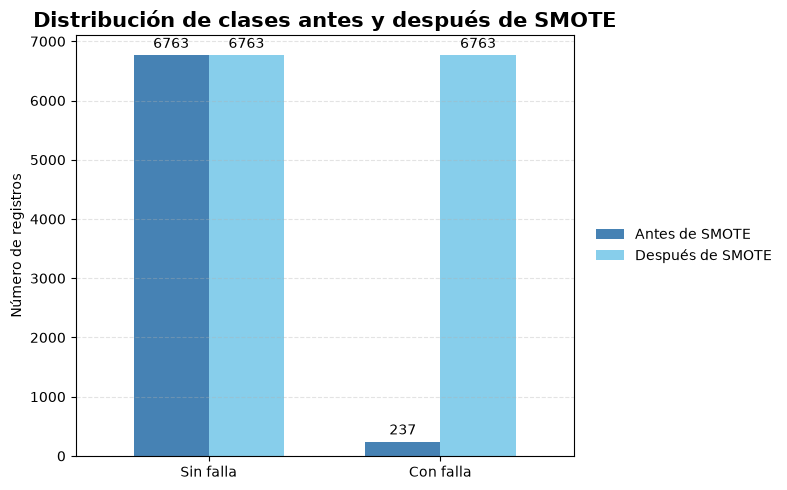

In [42]:
# Balanceo de clases mediante SMOTE

# Se aplica la técnica SMOTE únicamente sobre el conjunto de
# entrenamiento para equilibrar la cantidad de ejemplos de
# ambas clases antes del entrenamiento de los modelos.

smote = SMOTE(random_state=42)

X_train_balanced, y_train_balanced = smote.fit_resample(
    X_train_scaled,
    y_train
)

# Comparar la distribución de clases antes y después de SMOTE
balance = pd.DataFrame({
    "Antes de SMOTE": y_train.value_counts().sort_index(),
    "Después de SMOTE": y_train_balanced.value_counts().sort_index()
})

balance.index = ["Sin falla", "Con falla"]

print("Distribución de clases antes y después de aplicar SMOTE:\n")
display(balance)

# ==========================================================
# Visualización del balance de clases
# ==========================================================

fig, ax = plt.subplots(figsize=(8, 5))

balance.plot(
    kind="bar",
    ax=ax,
    color=["steelblue", "skyblue"],
    width=0.65
)

# Agregar etiquetas con la cantidad de registros
for container in ax.containers:
    ax.bar_label(container, fmt="%d", padding=3)

plt.title(
    "Distribución de clases antes y después de SMOTE",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("")
plt.ylabel("Número de registros")

plt.xticks(rotation=0)

# Cuadrícula para facilitar la lectura
plt.grid(axis="y", linestyle="--", alpha=0.35)

# Ubicar la leyenda fuera del gráfico
plt.legend(
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=False,
    title=""
)

plt.tight_layout()

plt.show()

**Qué vemos**

Antes de aplicar SMOTE, el conjunto de entrenamiento tenía 6.763 registros sin falla y 237 con falla. Después del balanceo, ambas clases quedaron representadas por 6.763 registros. Los conjuntos de validación y prueba no se modificaron, manteniendo su distribución original para evaluar el comportamiento del modelo posteriormente.

## 7. Entrenamiento de modelos

Entrenamos los modelos utilizando los datos del conjunto de entrenamiento previamente balanceados. Posteriormente, evaluamos su desempeño sobre el conjunto de validación para comparar las distintas técnicas y arquitecturas. El conjunto de prueba se mantiene separado y reservado para la evaluación final.

**Machine Learning:**
- Random Forest
- XGBoost
- Regresión Logística

**Deep Learning (redes neuronales tipo MLP):**
- Arquitectura A — superficial (1 capa)
- Arquitectura B — profunda (3 capas)
- Arquitectura C — ancha (1 capa grande)

### 7.1 Random Forest

In [43]:
# Entrenamiento del modelo Random Forest

# Se entrena un bosque aleatorio utilizando el conjunto
# de entrenamiento previamente balanceado con SMOTE.

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(
    X_train_balanced,
    y_train_balanced
)

# Predicciones sobre el conjunto de validación
y_pred_rf = rf_model.predict(X_val_scaled)

print("Modelo Random Forest entrenado correctamente.")

Modelo Random Forest entrenado correctamente.


### 7.2 XGBoost

In [45]:
# Entrenamiento del modelo XGBoost

# Se entrena un modelo basado en Gradient Boosting
# optimizado para tareas de clasificación.

xgb_model = XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)

xgb_model.fit(
    X_train_balanced,
    y_train_balanced
)

# Predicciones sobre el conjunto de validación
y_pred_xgb = xgb_model.predict(X_val_scaled)

print("Modelo XGBoost entrenado correctamente.")

Modelo XGBoost entrenado correctamente.


### 7.3 Regresión Logística

Agregamos Regresión Logística como tercera técnica de ML. A diferencia de Random Forest y XGBoost, que combinan muchos árboles, la Regresión Logística es un modelo lineal simple — sirve para comparar contra los modelos más complejos.

In [47]:
# Entrenamiento del modelo de Regresión Logística

# Se entrena un modelo lineal como línea base clásica,
# utilizando el mismo conjunto de entrenamiento balanceado con SMOTE.

from sklearn.linear_model import LogisticRegression

log_reg_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

log_reg_model.fit(
    X_train_balanced,
    y_train_balanced
)

# Predicciones sobre el conjunto de validación
y_pred_lr = log_reg_model.predict(X_val_scaled)

print("Modelo de Regresión Logística entrenado correctamente.")

Modelo de Regresión Logística entrenado correctamente.


c:\Users\javic\miniconda3\envs\ml\Lib\site-packages\sklearn\linear_model\_logistic.py:455: OptimizeWarning: Unknown solver options: iprint
  opt_res = optimize.minimize(


### 7.4 Arquitecturas de Deep Learning

Probamos tres redes neuronales (MLP) con distinta cantidad de capas y neuronas, para ver si una red más grande o más profunda funciona mejor. Las tres usan la activación ReLU y el optimizador Adam.

- **Arquitectura A (superficial):** 1 capa de 16 neuronas.
- **Arquitectura B (profunda):** 3 capas (64, 32, 16 neuronas).
- **Arquitectura C (ancha):** 1 capa de 128 neuronas.

In [48]:
# Entrenamiento de la Arquitectura A: MLP superficial

# Red neuronal con una única capa oculta de 16 neuronas.

mlp_shallow_model = MLPClassifier(
    hidden_layer_sizes=(16,),
    activation="relu",
    solver="adam",
    max_iter=500,
    random_state=42
)

mlp_shallow_model.fit(
    X_train_balanced,
    y_train_balanced
)

# Predicciones sobre el conjunto de validación
y_pred_mlp_shallow = mlp_shallow_model.predict(X_val_scaled)

print("Modelo MLP superficial (Arquitectura A) entrenado correctamente.")

Modelo MLP superficial (Arquitectura A) entrenado correctamente.


c:\Users\javic\miniconda3\envs\ml\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


#### 7.4.2 Arquitectura B — MLP profunda

In [49]:
# Entrenamiento de la Arquitectura B: MLP profunda

# Red neuronal con tres capas ocultas (64, 32, 16 neuronas).

mlp_model = MLPClassifier(
    hidden_layer_sizes=(64, 32, 16),
    activation="relu",
    solver="adam",
    max_iter=500,
    random_state=42
)

mlp_model.fit(
    X_train_balanced,
    y_train_balanced
)

# Predicciones sobre el conjunto de validación
y_pred_mlp = mlp_model.predict(X_val_scaled)

print("Modelo MLP profundo (Arquitectura B) entrenado correctamente.")

Modelo MLP profundo (Arquitectura B) entrenado correctamente.


#### 7.4.3 Arquitectura C — MLP ancha

In [50]:
# Entrenamiento de la Arquitectura C: MLP ancha

# Red neuronal con una única capa oculta de 128 neuronas.

mlp_wide_model = MLPClassifier(
    hidden_layer_sizes=(128,),
    activation="relu",
    solver="adam",
    max_iter=500,
    random_state=42
)

mlp_wide_model.fit(
    X_train_balanced,
    y_train_balanced
)

# Predicciones sobre el conjunto de validación
y_pred_mlp_wide = mlp_wide_model.predict(X_val_scaled)

print("Modelo MLP ancho (Arquitectura C) entrenado correctamente.")

Modelo MLP ancho (Arquitectura C) entrenado correctamente.


#### 7.4.4 Convergencia de las tres arquitecturas

Antes de comparar el desempeño, revisamos cómo bajó la pérdida (log-loss) de entrenamiento en cada red. Esto ayuda a ver si cada arquitectura llegó a converger y si hay señales de sobreajuste.

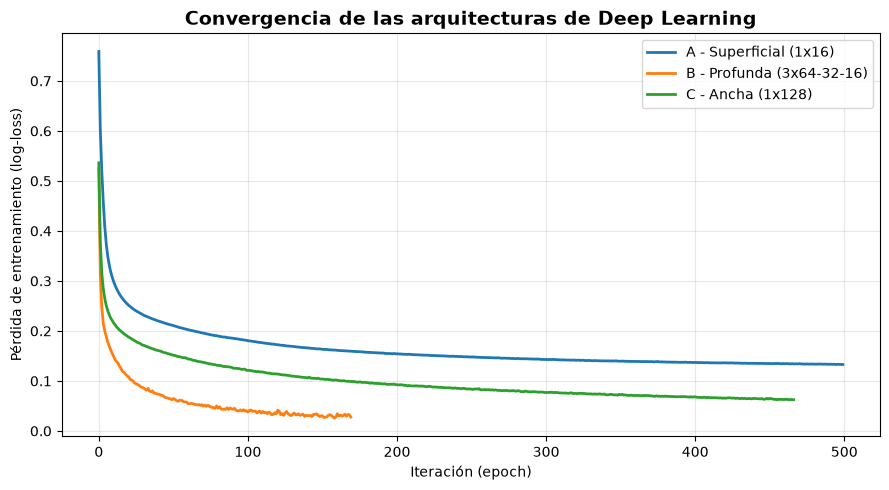

,Arquitectura,Iteraciones ejecutadas,¿Convergió?,Pérdida final
0,A - Superficial (1x16),500,No (alcanzó max_iter),0.1328
1,B - Profunda (3x64-32-16),170,Sí,0.0278
2,C - Ancha (1x128),467,Sí,0.0624


In [28]:
# Curvas de pérdida (loss) de entrenamiento de las tres arquitecturas MLP
redes = {
    "A - Superficial (1x16)": mlp_shallow_model,
    "B - Profunda (3x64-32-16)": mlp_model,
    "C - Ancha (1x128)": mlp_wide_model,
}

plt.figure(figsize=(9, 5))
for nombre, modelo in redes.items():
    plt.plot(modelo.loss_curve_, label=nombre, linewidth=2)
plt.title("Convergencia de las arquitecturas de Deep Learning", fontsize=14, fontweight="bold")
plt.xlabel("Iteración (epoch)")
plt.ylabel("Pérdida de entrenamiento (log-loss)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Resumen de convergencia
resumen_convergencia = pd.DataFrame([
    {
        "Arquitectura": nombre,
        "Iteraciones ejecutadas": modelo.n_iter_,
        "¿Convergió?": "Sí" if modelo.n_iter_ < modelo.max_iter else "No (alcanzó max_iter)",
        "Pérdida final": round(float(modelo.loss_curve_[-1]), 4),
    }
    for nombre, modelo in redes.items()
])
display(resumen_convergencia)

**Qué vemos**

La red profunda (B) reduce la pérdida de entrenamiento más rápidamente y alcanza la pérdida final más baja, deteniéndose por convergencia en 170 iteraciones. La red ancha (C) también converge, aunque necesita más iteraciones, mientras que la red superficial (A) alcanza el máximo de 500 iteraciones sin cumplir el criterio de convergencia.

Estos resultados muestran diferencias en la velocidad de aprendizaje y convergencia entre las arquitecturas. Sin embargo, la convergencia y la pérdida de entrenamiento por sí solas no permiten determinar cuál arquitectura generaliza mejor; esa comparación se realizará posteriormente utilizando el conjunto de validación.

**Resumen**

Entrenamos 6 modelos en total (3 de ML y 3 de DL) con los mismos datos de entrenamiento balanceados. Ahora toca evaluarlos y ver cuál predice mejor.

## 8. Evaluación de modelos

Evaluamos los modelos con el conjunto de validación, que se mantiene separado del entrenamiento. Usamos las métricas Precision, Recall, F1-Score, Accuracy y AUC-ROC para comparar su desempeño. El conjunto de prueba se mantiene reservado para la evaluación final del modelo seleccionado.

### 8.1 Reportes de clasificación

Vemos el reporte de cada modelo por separado.

In [51]:
# 8.1 Reportes de clasificación

# Evaluación de cada modelo sobre el conjunto de validación.
# El conjunto de prueba se mantiene reservado para la evaluación final.

def evaluar_modelo(modelo, X_eval, y_real, nombre_modelo):
    y_pred = modelo.predict(X_eval)
    y_proba = modelo.predict_proba(X_eval)[:, 1]

    print("=" * 60)
    print(nombre_modelo)
    print("=" * 60)
    print(classification_report(y_real, y_pred, digits=4))

    auc = roc_auc_score(y_real, y_proba)
    print(f"AUC-ROC (calculado sobre probabilidades): {auc:.4f}\n")

    return auc


auc_rf_correcto = evaluar_modelo(
    rf_model,
    X_val_scaled,
    y_val,
    "Random Forest"
)

auc_xgb_correcto = evaluar_modelo(
    xgb_model,
    X_val_scaled,
    y_val,
    "XGBoost"
)

auc_lr_correcto = evaluar_modelo(
    log_reg_model,
    X_val_scaled,
    y_val,
    "Regresión Logística"
)

auc_mlp_shallow_correcto = evaluar_modelo(
    mlp_shallow_model,
    X_val_scaled,
    y_val,
    "MLP superficial (DL - Arquitectura A)"
)

auc_mlp_correcto = evaluar_modelo(
    mlp_model,
    X_val_scaled,
    y_val,
    "MLP profunda (DL - Arquitectura B)"
)

auc_mlp_wide_correcto = evaluar_modelo(
    mlp_wide_model,
    X_val_scaled,
    y_val,
    "MLP ancha (DL - Arquitectura C)"
)

Random Forest
              precision    recall  f1-score   support

           0     0.9895    0.9765    0.9830      1449
           1     0.5143    0.7059    0.5950        51

    accuracy                         0.9673      1500
   macro avg     0.7519    0.8412    0.7890      1500
weighted avg     0.9734    0.9673    0.9698      1500

AUC-ROC (calculado sobre probabilidades): 0.9726

XGBoost
              precision    recall  f1-score   support

           0     0.9916    0.9827    0.9872      1449
           1     0.6094    0.7647    0.6783        51

    accuracy                         0.9753      1500
   macro avg     0.8005    0.8737    0.8327      1500
weighted avg     0.9786    0.9753    0.9767      1500

AUC-ROC (calculado sobre probabilidades): 0.9792

Regresión Logística
              precision    recall  f1-score   support

           0     0.9895    0.8454    0.9118      1449
           1     0.1450    0.7451    0.2428        51

    accuracy                         0.8

**Qué vemos**

La comparación sobre el conjunto de validación muestra diferencias importantes en la detección de la clase “con falla”. XGBoost presenta el mejor equilibrio entre Precision, Recall y F1-Score, alcanzando un F1 de 0.6783 y el AUC-ROC más alto, con 0.9792.

La MLP superficial (Arquitectura A) obtiene el mayor Recall (0.9020), pero su Precision es considerablemente menor (0.3511), lo que implica una mayor cantidad de falsas alarmas. La MLP ancha (Arquitectura C) también alcanza un Recall elevado (0.8627), aunque con un F1 inferior al de XGBoost.

La Regresión Logística presenta el menor desempeño general, principalmente por su baja Precision (0.1450). En función de este equilibrio entre capacidad de detección y cantidad de falsas alarmas, XGBoost queda como la alternativa candidata para continuar con el proceso de selección y refinamiento.

### 8.2 Tabla comparativa

Juntamos las métricas de los 6 modelos en una sola tabla para compararlos más fácil.

In [52]:
# 8.2 Tabla comparativa

# Comparación de los seis modelos sobre el conjunto de validación.
# El conjunto de prueba se mantiene reservado para la evaluación final.

modelos = {
    "Random Forest": rf_model,
    "XGBoost": xgb_model,
    "Regresión Logística": log_reg_model,
    "MLP superficial (DL-A)": mlp_shallow_model,
    "MLP profunda (DL-B)": mlp_model,
    "MLP ancha (DL-C)": mlp_wide_model
}

filas = []

for nombre, modelo in modelos.items():
    y_pred = modelo.predict(X_val_scaled)
    y_proba = modelo.predict_proba(X_val_scaled)[:, 1]

    filas.append({
        "Accuracy": accuracy_score(y_val, y_pred),
        "Precision": precision_score(y_val, y_pred, zero_division=0),
        "Recall": recall_score(y_val, y_pred, zero_division=0),
        "F1-Score": f1_score(y_val, y_pred),
        "AUC-ROC": roc_auc_score(y_val, y_proba)
    })

comparacion = pd.DataFrame(
    filas,
    index=list(modelos.keys())
).round(4)

display(comparacion)

,Accuracy,Precision,Recall,F1-Score,AUC-ROC
Random Forest,0.9673,0.5143,0.7059,0.5950,0.9726
XGBoost,0.9753,0.6094,0.7647,0.6783,0.9792
Regresión Logística,0.8420,0.1450,0.7451,0.2428,0.8775
MLP superficial (DL-A),0.9400,0.3511,0.9020,0.5055,0.9701
MLP profunda (DL-B),0.9713,0.5606,0.7255,0.6325,0.9499
MLP ancha (DL-C),0.9633,0.4783,0.8627,0.6154,0.9754


**Qué vemos**

XGBoost presenta el mejor desempeño general sobre el conjunto de validación, alcanzando un F1-Score de 0.6783 y un AUC-ROC de 0.9792, además de un Recall de 0.7647 para la detección de fallas.

La MLP superficial obtiene el mayor Recall (0.9020), pero presenta una Precision considerablemente menor (0.3511), lo que implica una mayor cantidad de falsas alarmas. La MLP ancha también logra un Recall elevado (0.8627) y un AUC-ROC de 0.9754, aunque su F1-Score queda por debajo de XGBoost.

Random Forest y la MLP profunda presentan un desempeño intermedio, mientras que Regresión Logística obtiene el menor F1-Score y AUC-ROC de las alternativas evaluadas. Estos resultados permiten considerar a XGBoost como candidato para la siguiente etapa de refinamiento, manteniendo el conjunto de prueba reservado para la evaluación final.

### 8.3 Comparar estrategias de balanceo

Probamos XGBoost con distintas estrategias para tratar el desbalance de clases, utilizando el conjunto de validación para comparar su desempeño. El conjunto de prueba se mantiene reservado para la evaluación final.

Escenario 1 — Sin balanceo (baseline)
Escenario 2 — Submuestreo (Undersampling)
Escenario 3 — Sobremuestreo aleatorio (Random Oversampling)
Escenario 4 — SMOTE

Las técnicas de remuestreo se aplican únicamente al conjunto de entrenamiento. Los conjuntos de validación y prueba se mantienen sin modificar.

ESCENARIO: 1. Sin balanceo de clases
Registros de entrenamiento: 7000 (clase positiva: 237 = 3.39 %)
              precision    recall  f1-score   support

   Sin falla     0.9883    0.9931    0.9907      1449
   Con falla     0.7727    0.6667    0.7158        51

    accuracy                         0.9820      1500
   macro avg     0.8805    0.8299    0.8532      1500
weighted avg     0.9810    0.9820    0.9814      1500

Accuracy : 0.9820
Precision: 0.7727
Recall   : 0.6667
F1-Score : 0.7158
AUC-ROC  : 0.9820

ESCENARIO: 2. Con submuestreo (Undersampling)
Registros de entrenamiento: 474 (clase positiva: 237 = 50.00 %)
              precision    recall  f1-score   support

   Sin falla     0.9985    0.9061    0.9501      1449
   Con falla     0.2649    0.9608    0.4153        51

    accuracy                         0.9080      1500
   macro avg     0.6317    0.9335    0.6827      1500
weighted avg     0.9735    0.9080    0.9319      1500

Accuracy : 0.9080
Precision: 0.2649
Recall  

,N° entrenamiento,% clase positiva,Accuracy,Precision,Recall,F1-Score,AUC-ROC
Escenario,,,,,,,
1. Sin balanceo de clases,7000,3.39,0.9820,0.7727,0.6667,0.7158,0.9820
2. Con submuestreo (Undersampling),474,50.00,0.9080,0.2649,0.9608,0.4153,0.9713
3. Con sobremuestreo aleatorio (Random Oversampling),13526,50.00,0.9827,0.7551,0.7255,0.7400,0.9835
4. Con SMOTE,13526,50.00,0.9753,0.6094,0.7647,0.6783,0.9792


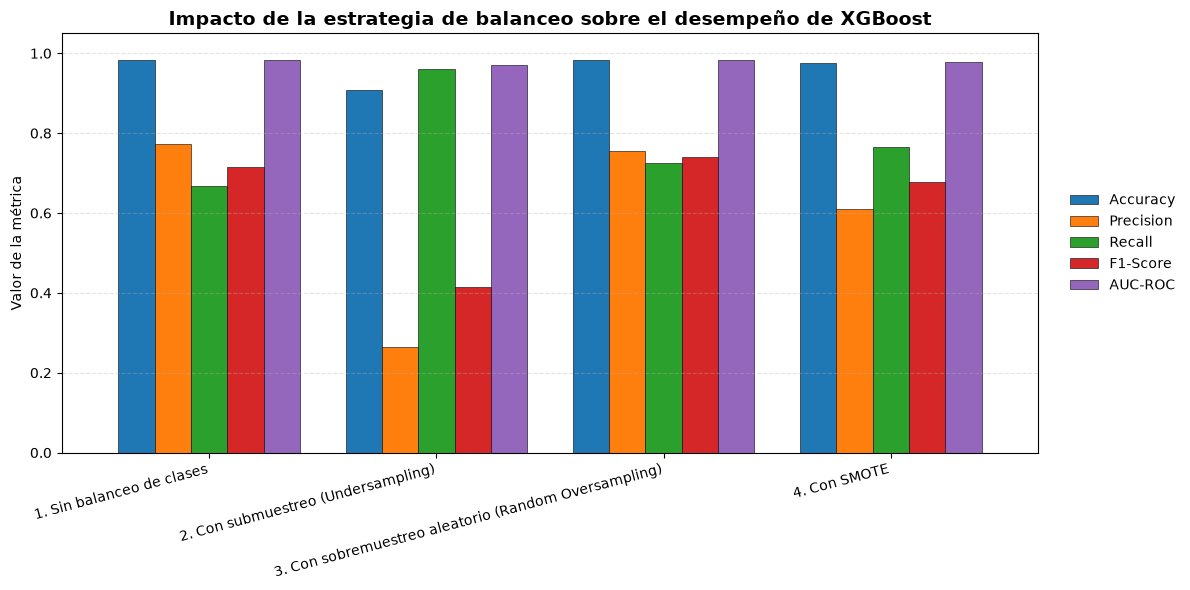

In [53]:
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import RandomOverSampler, SMOTE

RANDOM_STATE = 42


def entrenar_y_evaluar(X_tr, y_tr, X_eval, y_eval, nombre_escenario):
    """Entrena XGBoost y reporta las cinco métricas sobre validación."""
    
    modelo = XGBClassifier(
        random_state=RANDOM_STATE,
        eval_metric="logloss"
    )
    
    modelo.fit(X_tr, y_tr)

    y_pred = modelo.predict(X_eval)
    y_proba = modelo.predict_proba(X_eval)[:, 1]

    metricas = {
        "Escenario": nombre_escenario,
        "N° entrenamiento": len(y_tr),
        "% clase positiva": round(y_tr.mean() * 100, 2),
        "Accuracy": round(accuracy_score(y_eval, y_pred), 4),
        "Precision": round(precision_score(y_eval, y_pred, zero_division=0), 4),
        "Recall": round(recall_score(y_eval, y_pred), 4),
        "F1-Score": round(f1_score(y_eval, y_pred), 4),
        "AUC-ROC": round(roc_auc_score(y_eval, y_proba), 4),
    }

    print("=" * 70)
    print(f"ESCENARIO: {nombre_escenario}")
    print("=" * 70)
    print(
        f"Registros de entrenamiento: {len(y_tr)} "
        f"(clase positiva: {int(y_tr.sum())} = {y_tr.mean()*100:.2f} %)"
    )
    
    print(
        classification_report(
            y_eval,
            y_pred,
            digits=4,
            target_names=["Sin falla", "Con falla"]
        )
    )
    
    print(f"Accuracy : {metricas['Accuracy']:.4f}")
    print(f"Precision: {metricas['Precision']:.4f}")
    print(f"Recall   : {metricas['Recall']:.4f}")
    print(f"F1-Score : {metricas['F1-Score']:.4f}")
    print(f"AUC-ROC  : {metricas['AUC-ROC']:.4f}\n")

    return metricas, modelo


resultados_escenarios = []


# ==========================================================
# Escenario 1: sin balanceo (baseline)
# ==========================================================

m1, modelo_sin_balanceo = entrenar_y_evaluar(
    X_train_scaled,
    y_train,
    X_val_scaled,
    y_val,
    "1. Sin balanceo de clases"
)

resultados_escenarios.append(m1)


# ==========================================================
# Escenario 2: submuestreo (Undersampling)
# ==========================================================

rus = RandomUnderSampler(
    random_state=RANDOM_STATE
)

X_train_under, y_train_under = rus.fit_resample(
    X_train_scaled,
    y_train
)

m2, modelo_undersampling = entrenar_y_evaluar(
    X_train_under,
    y_train_under,
    X_val_scaled,
    y_val,
    "2. Con submuestreo (Undersampling)"
)

resultados_escenarios.append(m2)


# ==========================================================
# Escenario 3: sobremuestreo aleatorio (Random Oversampling)
# ==========================================================

ros = RandomOverSampler(
    random_state=RANDOM_STATE
)

X_train_over, y_train_over = ros.fit_resample(
    X_train_scaled,
    y_train
)

m3, modelo_oversampling = entrenar_y_evaluar(
    X_train_over,
    y_train_over,
    X_val_scaled,
    y_val,
    "3. Con sobremuestreo aleatorio (Random Oversampling)"
)

resultados_escenarios.append(m3)


# ==========================================================
# Escenario 4: SMOTE
# ==========================================================

smote = SMOTE(
    random_state=RANDOM_STATE
)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_scaled,
    y_train
)

m4, modelo_smote = entrenar_y_evaluar(
    X_train_smote,
    y_train_smote,
    X_val_scaled,
    y_val,
    "4. Con SMOTE"
)

resultados_escenarios.append(m4)


# ==========================================================
# Tabla resumen
# ==========================================================

tabla_escenarios = pd.DataFrame(
    resultados_escenarios
).set_index("Escenario")

print("=" * 70)
print("RESUMEN COMPARATIVO DE ESCENARIOS DE BALANCEO")
print("=" * 70)

display(tabla_escenarios)


# ==========================================================
# Gráfico comparativo
# ==========================================================

metricas_plot = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-Score",
    "AUC-ROC"
]

ax = tabla_escenarios[metricas_plot].plot(
    kind="bar",
    figsize=(12, 6),
    width=0.8,
    edgecolor="black",
    linewidth=0.4
)

ax.set_title(
    "Impacto de la estrategia de balanceo sobre el desempeño de XGBoost",
    fontsize=14,
    fontweight="bold"
)

ax.set_ylabel("Valor de la métrica")
ax.set_xlabel("")
ax.set_ylim(0, 1.05)

ax.legend(
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=False
)

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.35
)

plt.xticks(
    rotation=15,
    ha="right"
)

plt.tight_layout()
plt.show()

**Qué vemos**

Sin balanceo, XGBoost obtiene una alta Precision (0.7727) y Accuracy (0.9820), pero su Recall baja a 0.6667, por lo que deja sin detectar una mayor proporción de las fallas.

El submuestreo alcanza el mayor Recall (0.9608), pero reduce considerablemente la Precision (0.2649) y el F1-Score (0.4153), debido a que elimina una gran cantidad de registros de la clase mayoritaria durante el entrenamiento.

El sobremuestreo aleatorio presenta el mejor equilibrio entre las métricas, alcanzando el mayor F1-Score (0.7400) y el AUC-ROC más alto (0.9835), además de mantener una Precision de 0.7551 y un Recall de 0.7255.

SMOTE también mejora la detección de fallas respecto al modelo sin balanceo, pero obtiene un F1-Score y AUC-ROC inferiores al sobremuestreo aleatorio. Por estos resultados, Random Oversampling queda como la estrategia candidata para continuar con el refinamiento de XGBoost.

### 8.4 GridSearchCV

Probamos distintas combinaciones de hiperparámetros de XGBoost mediante validación cruzada estratificada de 5 particiones, utilizando únicamente el conjunto de entrenamiento. Como estrategia de balanceo se utiliza Random Oversampling, seleccionada a partir de la comparación realizada sobre el conjunto de validación.

La selección de hiperparámetros se realiza optimizando el F1-Score, ya que el problema presenta un fuerte desbalance entre las clases. Una vez obtenida la mejor configuración, su desempeño se evalúa sobre el conjunto de validación. El conjunto de prueba se mantiene reservado para la evaluación final.

In [54]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from imblearn.over_sampling import RandomOverSampler
from imblearn.pipeline import Pipeline
import time

RANDOM_STATE = 42

# ==========================================================
# Pipeline: Random Oversampling + XGBoost
# El balanceo se realiza dentro de cada fold de CV
# para evitar filtración entre entrenamiento y validación.
# ==========================================================

pipeline_xgb = Pipeline([
    ("oversampler", RandomOverSampler(random_state=RANDOM_STATE)),
    ("xgb", XGBClassifier(
        random_state=RANDOM_STATE,
        eval_metric="logloss"
    ))
])

# ==========================================================
# Grilla de hiperparámetros de XGBoost
# ==========================================================

param_grid = {
    "xgb__n_estimators":     [100, 200, 300],
    "xgb__max_depth":        [3, 5, 7],
    "xgb__learning_rate":    [0.01, 0.1, 0.2],
    "xgb__subsample":        [0.8, 1.0],
    "xgb__colsample_bytree": [0.8, 1.0],
}

total_combinaciones = np.prod([
    len(v) for v in param_grid.values()
])

print(f"Combinaciones a evaluar: {total_combinaciones}")
print(f"Ajustes totales (5 folds): {total_combinaciones * 5}\n")

# ==========================================================
# Validación cruzada estratificada
# ==========================================================

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

grid_search = GridSearchCV(
    estimator=pipeline_xgb,
    param_grid=param_grid,
    scoring="f1",
    cv=cv,
    n_jobs=-1,
    verbose=1,
    return_train_score=False
)

# ==========================================================
# Búsqueda de hiperparámetros SOLO sobre entrenamiento
# ==========================================================

inicio = time.time()

grid_search.fit(
    X_train_scaled,
    y_train
)

duracion = time.time() - inicio

print(f"\nBúsqueda completada en {duracion/60:.2f} minutos.\n")

# ==========================================================
# Mejores hiperparámetros encontrados
# ==========================================================

print("=" * 70)
print("MEJORES HIPERPARÁMETROS")
print("=" * 70)

for parametro, valor in grid_search.best_params_.items():
    parametro_limpio = parametro.replace("xgb__", "")
    print(f"  {parametro_limpio:<20}: {valor}")

print(
    f"\nMejor F1-Score en validación cruzada: "
    f"{grid_search.best_score_:.4f}"
)

# ==========================================================
# Evaluación del modelo optimizado sobre VALIDACIÓN
# ==========================================================

mejor_xgb = grid_search.best_estimator_

y_pred_opt = mejor_xgb.predict(X_val_scaled)
y_proba_opt = mejor_xgb.predict_proba(X_val_scaled)[:, 1]

print("\n" + "=" * 70)
print("DESEMPEÑO DEL MODELO OPTIMIZADO SOBRE VALIDACIÓN")
print("=" * 70)

print(
    classification_report(
        y_val,
        y_pred_opt,
        digits=4,
        target_names=["Sin falla", "Con falla"]
    )
)

# ==========================================================
# Comparación: XGBoost baseline con Random Oversampling
# vs. XGBoost optimizado
# ==========================================================

y_pred_base = modelo_oversampling.predict(X_val_scaled)
y_proba_base = modelo_oversampling.predict_proba(X_val_scaled)[:, 1]

comparacion_tuning = pd.DataFrame({
    "XGBoost baseline (ROS)": [
        accuracy_score(y_val, y_pred_base),
        precision_score(y_val, y_pred_base, zero_division=0),
        recall_score(y_val, y_pred_base),
        f1_score(y_val, y_pred_base),
        roc_auc_score(y_val, y_proba_base),
    ],
    "XGBoost optimizado (GridSearchCV)": [
        accuracy_score(y_val, y_pred_opt),
        precision_score(y_val, y_pred_opt, zero_division=0),
        recall_score(y_val, y_pred_opt),
        f1_score(y_val, y_pred_opt),
        roc_auc_score(y_val, y_proba_opt),
    ],
}, index=[
    "Accuracy",
    "Precision",
    "Recall",
    "F1-Score",
    "AUC-ROC"
]).round(4)

comparacion_tuning["Diferencia"] = (
    comparacion_tuning["XGBoost optimizado (GridSearchCV)"]
    - comparacion_tuning["XGBoost baseline (ROS)"]
).round(4)

print("\n" + "=" * 70)
print("COMPARACIÓN: BASELINE VS. MODELO OPTIMIZADO")
print("=" * 70)

display(comparacion_tuning)

# ==========================================================
# Cinco mejores configuraciones de la búsqueda
# ==========================================================

resultados_cv = (
    pd.DataFrame(grid_search.cv_results_)
    [["params", "mean_test_score", "std_test_score", "rank_test_score"]]
    .sort_values("rank_test_score")
    .head(5)
    .reset_index(drop=True)
)

print("\nCinco mejores configuraciones evaluadas:")
display(resultados_cv)

Combinaciones a evaluar: 108
Ajustes totales (5 folds): 540

Fitting 5 folds for each of 108 candidates, totalling 540 fits

Búsqueda completada en 0.36 minutos.

MEJORES HIPERPARÁMETROS
  colsample_bytree    : 1.0
  learning_rate       : 0.1
  max_depth           : 7
  n_estimators        : 300
  subsample           : 0.8

Mejor F1-Score en validación cruzada: 0.7323

DESEMPEÑO DEL MODELO OPTIMIZADO SOBRE VALIDACIÓN
              precision    recall  f1-score   support

   Sin falla     0.9910    0.9910    0.9910      1449
   Con falla     0.7451    0.7451    0.7451        51

    accuracy                         0.9827      1500
   macro avg     0.8681    0.8681    0.8681      1500
weighted avg     0.9827    0.9827    0.9827      1500


COMPARACIÓN: BASELINE VS. MODELO OPTIMIZADO


,XGBoost baseline (ROS),XGBoost optimizado (GridSearchCV),Diferencia
Accuracy,0.9827,0.9827,0.0000
Precision,0.7551,0.7451,-0.0100
Recall,0.7255,0.7451,0.0196
F1-Score,0.7400,0.7451,0.0051
AUC-ROC,0.9835,0.9847,0.0012



Cinco mejores configuraciones evaluadas:


,params,mean_test_score,std_test_score,rank_test_score
0,"{'xgb__colsample_bytree': 1.0, 'xgb__learning_...",0.732257,0.039139,1
1,"{'xgb__colsample_bytree': 1.0, 'xgb__learning_...",0.725717,0.033873,2
2,"{'xgb__colsample_bytree': 1.0, 'xgb__learning_...",0.722627,0.043414,3
3,"{'xgb__colsample_bytree': 0.8, 'xgb__learning_...",0.722442,0.028540,4
4,"{'xgb__colsample_bytree': 1.0, 'xgb__learning_...",0.720614,0.024180,5


**Qué vemos**

El ajuste de hiperparámetros mediante GridSearchCV produce una mejora moderada respecto al XGBoost baseline con Random Oversampling. El F1-Score aumenta de 0.7400 a 0.7451, mientras que el AUC-ROC pasa de 0.9835 a 0.9847 y el Recall aumenta de 0.7255 a 0.7451. La Accuracy se mantiene en 0.9827, mientras que la Precision presenta una leve disminución, de 0.7551 a 0.7451.

La mejor configuración encontrada mediante validación cruzada de 5 particiones utiliza 300 estimadores, profundidad máxima de 7, learning rate de 0.1, subsample de 0.8 y colsample_bytree de 1.0, obteniendo un F1-Score promedio de 0.7323 durante la validación cruzada.

En conjunto, los resultados indican que el ajuste de hiperparámetros mejora ligeramente el equilibrio entre detección de fallas y falsas alarmas. Por ello, XGBoost optimizado queda como candidato para la evaluación final, manteniendo el conjunto de prueba reservado y sin utilizarlo para tomar nuevas decisiones.

### 8.5 Matriz de confusión

Vemos en detalle cuántas predicciones acertó y cuántas erró el modelo, separado por clase.Vemos en detalle cuántas predicciones acertó y cuántas erró el modelo XGBoost optimizado sobre el conjunto de validación, separado por clase.

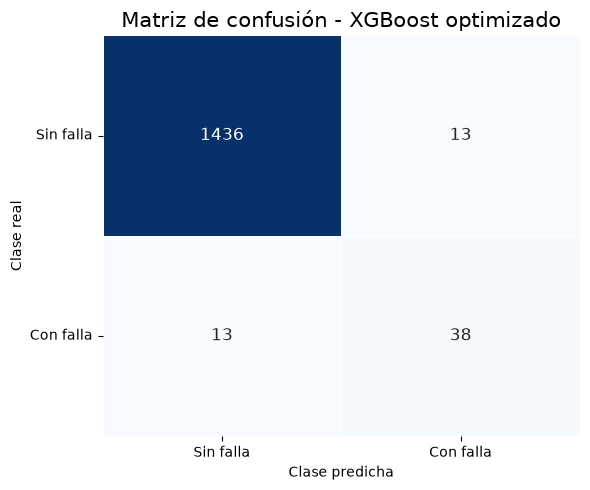

In [58]:
# Matriz de confusión del modelo XGBoost optimizado
# evaluado sobre el conjunto de validación.

cm = confusion_matrix(y_val, y_pred_opt)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    linewidths=0.5,
    annot_kws={"size": 12}
)

plt.title(
    "Matriz de confusión - XGBoost optimizado",
    fontsize=15
)

plt.xlabel("Clase predicha")
plt.ylabel("Clase real")

plt.xticks(
    [0.5, 1.5],
    ["Sin falla", "Con falla"]
)

plt.yticks(
    [0.5, 1.5],
    ["Sin falla", "Con falla"],
    rotation=0
)

plt.tight_layout()
plt.show()

**Qué vemos**

El modelo XGBoost optimizado clasificó correctamente 1.436 registros sin falla y 38 registros con falla. Se produjeron 13 falsos positivos, correspondientes a máquinas sin falla clasificadas como “con falla”, y 13 falsos negativos, correspondientes a máquinas con falla que el modelo no detectó.

En particular, los 13 falsos negativos representan los casos más relevantes desde el punto de vista del mantenimiento predictivo, ya que corresponden a fallas que no fueron detectadas por el modelo. En el conjunto de validación se identificaron correctamente 38 de las 51 fallas reales.

### 8.6 Curva ROC

La curva ROC muestra qué tan bien un modelo distingue entre “con falla” y “sin falla” a distintos umbrales de decisión. El AUC-ROC resume esta capacidad en un valor entre 0 y 1, donde valores más cercanos a 1 indican una mejor capacidad de discriminación. En esta etapa, las curvas se calculan sobre el conjunto de validación para comparar las alternativas antes de la evaluación final sobre el conjunto de prueba.

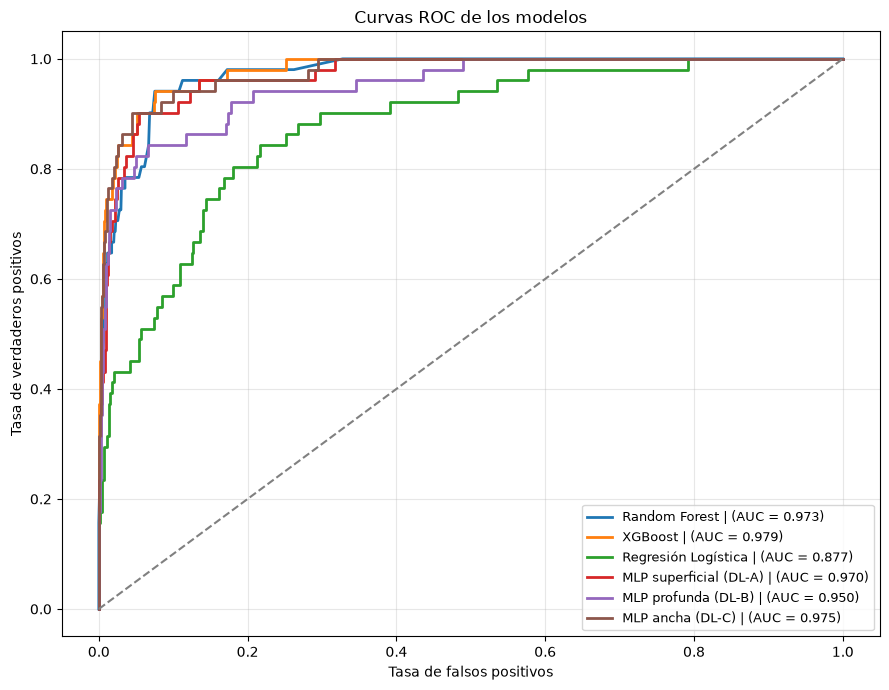

In [59]:
# Curvas ROC

# Se comparan las curvas ROC de los seis modelos utilizando
# las probabilidades estimadas para la clase positiva
# sobre el conjunto de validación.

from sklearn.metrics import roc_curve

modelos_roc = {
    "Random Forest": rf_model,
    "XGBoost": xgb_model,
    "Regresión Logística": log_reg_model,
    "MLP superficial (DL-A)": mlp_shallow_model,
    "MLP profunda (DL-B)": mlp_model,
    "MLP ancha (DL-C)": mlp_wide_model,
}

plt.figure(figsize=(9, 7))

for nombre, modelo in modelos_roc.items():
    proba = modelo.predict_proba(X_val_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_val, proba)
    auc = roc_auc_score(y_val, proba)

    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f"{nombre} | (AUC = {auc:.3f})"
    )

# Línea de referencia
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="gray"
)

plt.title("Curvas ROC de los modelos")
plt.xlabel("Tasa de falsos positivos")
plt.ylabel("Tasa de verdaderos positivos")

plt.legend(loc="lower right", fontsize=9)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Qué vemos**

Los seis modelos presentan una capacidad de discriminación superior a la línea de referencia, aunque existen diferencias entre ellos. XGBoost obtiene el mayor AUC-ROC (0.979), seguido por la MLP ancha (0.975) y Random Forest (0.973).

La MLP superficial alcanza un AUC de 0.970, mientras que la MLP profunda obtiene 0.950. Regresión Logística presenta el menor valor, con 0.877. Estos resultados son consistentes con la comparación realizada previamente sobre el conjunto de validación y respaldan a XGBoost como la alternativa con mejor capacidad global de discriminación entre las clases.

### 8.7 Elegir el mejor modelo

Con las métricas, la matriz de confusión y la curva ROC, elegimos el modelo con mejor desempeño para el problema.

In [60]:
# Selección del mejor modelo

# Se selecciona el XGBoost optimizado mediante GridSearchCV,
# utilizando Random Oversampling como estrategia de balanceo.

mejor_modelo = mejor_xgb

print("Modelo seleccionado para la etapa de interpretación:")
print("XGBoost optimizado con Random Oversampling")

Modelo seleccionado para la etapa de interpretación:
XGBoost optimizado con Random Oversampling


**Qué vemos**

Considerando los resultados obtenidos sobre el conjunto de validación, seleccionamos XGBoost optimizado con Random Oversampling como el modelo candidato para la evaluación final. Esta configuración alcanza un F1-Score de 0.7451, un Recall de 0.7451, una Precision de 0.7451, una Accuracy de 0.9827 y un AUC-ROC de 0.9847 sobre validación.

La optimización se realizó mediante GridSearchCV con validación cruzada de 5 particiones y obtuvo una configuración de 300 estimadores, profundidad máxima de 7, learning rate de 0.1, subsample de 0.8 y colsample_bytree de 1.0.

Con estas decisiones congeladas, el siguiente paso será realizar la evaluación final sobre el conjunto de prueba, que hasta este momento no ha sido utilizado para seleccionar el modelo.

## 9. Interpretabilidad con SHAP

No basta con que el modelo prediga bien, también queremos entender por qué predice lo que predice. Para eso usamos SHAP, que nos dice cuánto influye cada variable en cada predicción.

### 9.1 Preparar SHAP

Preparamos el XGBoost optimizado y el conjunto de validación para calcular los valores SHAP. Los datos escalados se mantienen en un DataFrame para conservar los nombres de las variables y facilitar la interpretación de las contribuciones de cada predictor.

In [61]:
# 9.1 Preparar SHAP

# Se prepara el modelo XGBoost optimizado para realizar
# el análisis de interpretabilidad mediante SHAP.

shap.initjs()

# Obtener el modelo XGBoost desde el pipeline
xgb_shap_model = mejor_modelo.named_steps["xgb"]

# Crear el explicador para el modelo XGBoost
explainer = shap.TreeExplainer(xgb_shap_model)

# Convertir el conjunto de validación escalado nuevamente
# en DataFrame para conservar los nombres de las variables
X_val_df = pd.DataFrame(
    X_val_scaled,
    columns=X.columns
)

print("Conjunto de validación preparado para el análisis SHAP:")
display(X_val_df.head())

Conjunto de validación preparado para el análisis SHAP:


,Air_temperature_K,Process_temperature_K,Rotational_speed_rpm,Torque_Nm,Tool_wear_min,Type_L,Type_M
0,1.241251,1.345480,-0.289846,0.609547,1.055075,-1.230964,1.539033
1,0.142641,-0.476958,-0.339784,-0.050103,1.133373,0.812372,-0.649758
2,0.841756,0.333014,1.025179,-0.699759,0.992438,-1.230964,1.539033
3,0.841756,0.400512,0.842074,-1.229478,-0.041084,-1.230964,1.539033
4,-0.606411,-0.071972,-0.078998,-0.030114,-0.479547,0.812372,-0.649758


**Qué vemos**

El conjunto de validación quedó preparado junto con el XGBoost optimizado para calcular los valores SHAP. Esto permitirá identificar qué variables tienen mayor influencia en las predicciones y en qué dirección contribuyen al resultado del modelo.

### 9.2 Importancia de las variables

Calculamos los valores SHAP y graficamos un resumen que muestra qué tanto influye cada variable en las predicciones.Calculamos los valores SHAP sobre el conjunto de validación para identificar cuánto influye cada variable en las predicciones del XGBoost optimizado. El gráfico resumen permite ordenar las variables según su importancia global y observar la dirección de su contribución.

Calculando valores SHAP...
Generando gráfico resumen de SHAP...


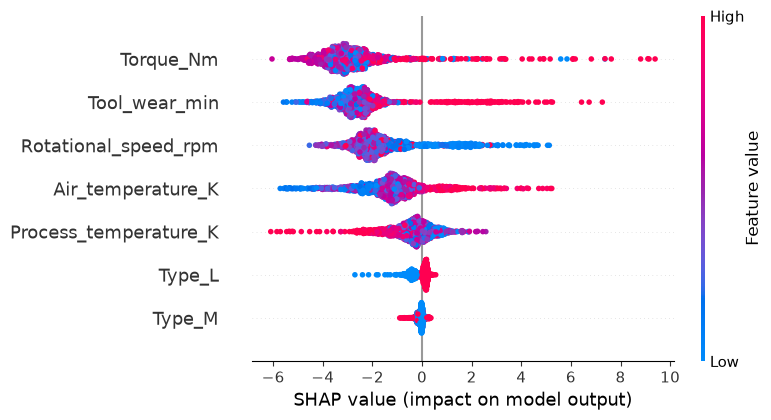

In [62]:
# Importancia de las variables con SHAP

# Se calculan los valores SHAP para conocer la contribución
# de cada variable en las predicciones realizadas por
# el modelo XGBoost optimizado sobre el conjunto de validación.

print("Calculando valores SHAP...")

# Calcular valores SHAP
shap_values = explainer.shap_values(X_val_df)

print("Generando gráfico resumen de SHAP...")

# Gráfico de importancia global
shap.summary_plot(
    shap_values,
    X_val_df,
    show=True
)

**Qué vemos**

El análisis SHAP muestra que Torque_Nm es la variable con mayor importancia global para las predicciones del modelo, seguida por Tool_wear_min y Rotational_speed_rpm. También presentan una influencia relevante Air_temperature_K y Process_temperature_K, mientras que las variables categóricas Type_L y Type_M tienen una contribución menor.

El gráfico también permite observar que valores altos y bajos de las variables pueden contribuir en distintas direcciones a la predicción. En particular, Torque_Nm y Tool_wear_min concentran las mayores magnitudes de valores SHAP, por lo que tienen una mayor influencia en la salida del modelo.

En conjunto, estos resultados permiten interpretar qué variables tienen mayor peso en la detección de fallas y aportan trazabilidad a las predicciones realizadas por XGBoost.

### 9.3 Explicación de casos particulares

El gráfico global muestra qué variables son más relevantes en promedio. Para comprender predicciones concretas, revisamos tres casos del conjunto de validación mediante gráficos de cascada (waterfall) de SHAP: una falla correctamente detectada, una falla no detectada (falso negativo) y una máquina sin falla correctamente clasificada.

CASO 1 - Verdadero positivo (falla detectada) | Clase real: 1 | Prob. de falla: 1.000


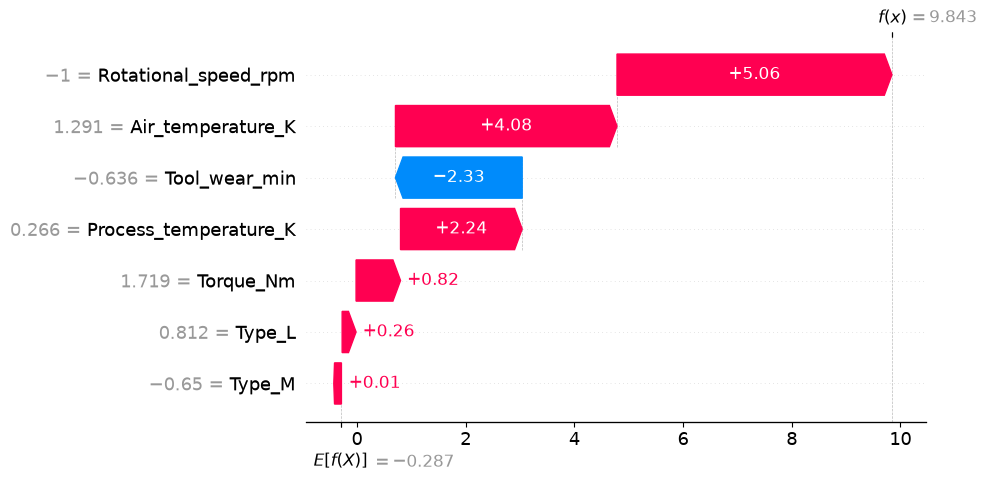

CASO 2 - Falso negativo (falla NO detectada) | Clase real: 1 | Prob. de falla: 0.001


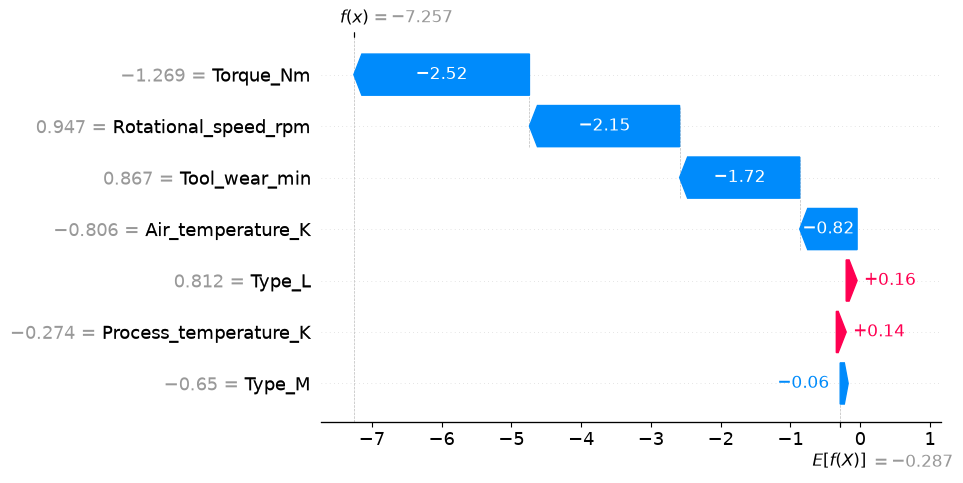

CASO 3 - Verdadero negativo (máquina sana) | Clase real: 0 | Prob. de falla: 0.000


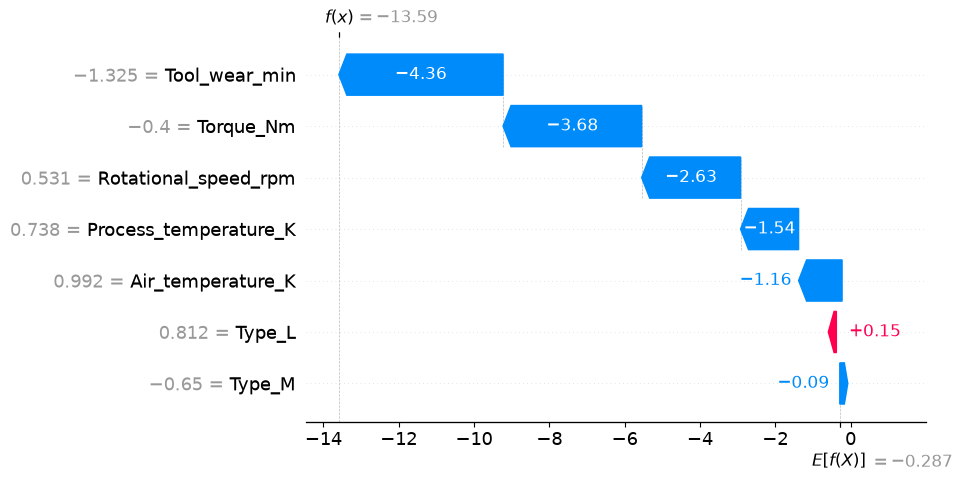

In [64]:
# 9.3 Explicación de casos particulares

# Seleccionamos tres casos del conjunto de validación:
# 1) Verdadero positivo: falla detectada
# 2) Falso negativo: falla no detectada
# 3) Verdadero negativo: máquina sana

proba_val = mejor_modelo.predict_proba(X_val_scaled)[:, 1]
y_val_arr = y_val.to_numpy()

UMBRAL = 0.5

# Verdadero positivo
mask_vp = (y_val_arr == 1) & (proba_val >= UMBRAL)
idx_vp = int(np.where(mask_vp)[0][np.argmax(proba_val[mask_vp])]) if mask_vp.any() else None

# Falso negativo
mask_fn = (y_val_arr == 1) & (proba_val < UMBRAL)
idx_fn = int(np.where(mask_fn)[0][np.argmin(proba_val[mask_fn])]) if mask_fn.any() else None

# Verdadero negativo
mask_vn = (y_val_arr == 0) & (proba_val < UMBRAL)
idx_vn = int(np.where(mask_vn)[0][np.argmin(proba_val[mask_vn])]) if mask_vn.any() else None


def explicar_caso(idx, titulo):
    if idx is None:
        print(f"No se encontró un caso disponible para: {titulo}")
        return

    print("=" * 70)
    print(
        f"{titulo} | "
        f"Clase real: {int(y_val_arr[idx])} | "
        f"Prob. de falla: {proba_val[idx]:.3f}"
    )
    print("=" * 70)

    # Crear explicación SHAP para el caso
    explicacion = shap.Explanation(
        values=shap_values[idx],
        base_values=explainer.expected_value,
        data=X_val_df.iloc[idx].values,
        feature_names=X_val_df.columns.tolist()
    )

    shap.plots.waterfall(
        explicacion,
        show=True
    )


explicar_caso(
    idx_vp,
    "CASO 1 - Verdadero positivo (falla detectada)"
)

explicar_caso(
    idx_fn,
    "CASO 2 - Falso negativo (falla NO detectada)"
)

explicar_caso(
    idx_vn,
    "CASO 3 - Verdadero negativo (máquina sana)"
)

**Qué vemos**

En el verdadero positivo, la predicción hacia “falla” está impulsada principalmente por la velocidad de rotación y la temperatura del aire, seguidas por la temperatura de proceso y el torque. En este caso, el desgaste de la herramienta aporta en sentido contrario, aunque las demás variables compensan esta influencia y mantienen la predicción hacia la clase de falla.

En el falso negativo ocurre lo contrario: el torque, la velocidad de rotación y el desgaste de la herramienta presentan contribuciones negativas importantes, por lo que el modelo reduce fuertemente su salida hacia “falla” y termina clasificando incorrectamente una máquina que realmente falló. Este caso muestra que una falla puede no estar acompañada por un patrón suficientemente claro en las variables disponibles en una observación individual.

En el verdadero negativo, el desgaste de la herramienta, el torque y la velocidad de rotación son los principales factores que contribuyen a mantener la predicción en “sin falla”.

**Qué vemos**

A nivel global, Torque_Nm es la variable con mayor influencia en las predicciones del modelo, seguida por Tool_wear_min y Rotational_speed_rpm. También tienen una contribución relevante las temperaturas de aire y de proceso, mientras que Type_L y Type_M presentan una influencia considerablemente menor.

Los casos particulares muestran que la importancia de una variable no implica que siempre actúe en la misma dirección: una misma característica puede aumentar o disminuir la salida del modelo dependiendo de los valores combinados de la observación.

## 10. Guardar el modelo

Guardamos tres archivos que la API necesitará para realizar predicciones: el modelo XGBoost optimizado, el StandardScaler utilizado durante el preprocesamiento y el orden de las columnas utilizado en el entrenamiento. La verificación de integridad se realiza sobre el conjunto de validación, manteniendo el conjunto de prueba reservado para la evaluación final.

In [69]:
# Guardamos tres archivos que la API necesita:
# 1. El XGBoost optimizado y entrenado
# 2. El StandardScaler ajustado con los datos de entrenamiento
# 3. El orden de las columnas utilizado durante el entrenamiento

import joblib
from pathlib import Path

ARTIFACTS = PROJECT_ROOT / "modelos"
ARTIFACTS.mkdir(exist_ok=True)

# Extraer el XGBoost entrenado desde el pipeline
modelo_produccion = mejor_modelo.named_steps["xgb"]

# Guardar modelo, scaler y orden de columnas
joblib.dump(
    modelo_produccion,
    ARTIFACTS / "modelo_xgboost.pkl"
)

joblib.dump(
    scaler,
    ARTIFACTS / "scaler.pkl"
)

joblib.dump(
    list(X.columns),
    ARTIFACTS / "columnas.pkl"
)

print("Artefactos guardados en:", ARTIFACTS.resolve())

print("Orden de columnas esperado por el modelo:")
for i, c in enumerate(X.columns):
    print(f"{i}. {c}")


# ----------------------------------------------------------
# Verificación de integridad usando VALIDACIÓN
# ----------------------------------------------------------

modelo_test = joblib.load(
    ARTIFACTS / "modelo_xgboost.pkl"
)

# Se verifica que el modelo guardado reproduzca
# una predicción del conjunto de validación.
prob_original = mejor_modelo.predict_proba(
    X_val_scaled
)[:, 1]

prob_recargado = modelo_test.predict_proba(
    X_val_scaled
)[:, 1]

print(
    f"Verificación de integridad: "
    f"{prob_original[0]:.6f} == {prob_recargado[0]:.6f} "
    f"=> {'OK' if abs(prob_original[0] - prob_recargado[0]) < 1e-9 else 'ERROR'}"
)

Artefactos guardados en: C:\Users\javic\Documents\Machine Learning\Proyecto\Sumativa 1\Proyecto sumativa 1\Proyecto Sumativa\modelos
Orden de columnas esperado por el modelo:
0. Air_temperature_K
1. Process_temperature_K
2. Rotational_speed_rpm
3. Torque_Nm
4. Tool_wear_min
5. Type_L
6. Type_M
Verificación de integridad: 0.000031 == 0.000031 => OK


## 11. Evaluación final sobre el conjunto de prueba.

Después de finalizar la selección del modelo, la estrategia de balanceo y la optimización de hiperparámetros utilizando exclusivamente los conjuntos de entrenamiento y validación, se realiza la evaluación final sobre el conjunto de prueba. Este conjunto se mantuvo reservado durante todo el proceso de selección y se utiliza una única vez para estimar el desempeño final del modelo.

### 11.1 Métricas finales

In [70]:
# ==========================================================
# 11.1 Evaluación final sobre el conjunto de prueba
# ==========================================================

# Todas las decisiones del modelo ya fueron tomadas utilizando
# entrenamiento y validación. El conjunto de prueba se utiliza
# una única vez para obtener la evaluación final.

modelo_final = mejor_modelo

# Predicciones finales sobre el conjunto de prueba
y_pred_test = modelo_final.predict(X_test_scaled)
y_proba_test = modelo_final.predict_proba(X_test_scaled)[:, 1]

# Métricas finales
metricas_finales = pd.DataFrame({
    "Métrica": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "AUC-ROC"
    ],
    "Resultado": [
        accuracy_score(y_test, y_pred_test),
        precision_score(y_test, y_pred_test, zero_division=0),
        recall_score(y_test, y_pred_test),
        f1_score(y_test, y_pred_test),
        roc_auc_score(y_test, y_proba_test)
    ]
}).round(4)

print("=" * 70)
print("EVALUACIÓN FINAL SOBRE EL CONJUNTO DE PRUEBA")
print("=" * 70)

display(metricas_finales)

print("\nReporte de clasificación:")
print(
    classification_report(
        y_test,
        y_pred_test,
        digits=4,
        target_names=["Sin falla", "Con falla"]
    )
)

EVALUACIÓN FINAL SOBRE EL CONJUNTO DE PRUEBA


,Métrica,Resultado
0,Accuracy,0.9840
1,Precision,0.7755
2,Recall,0.7451
3,F1-Score,0.7600
4,AUC-ROC,0.9770



Reporte de clasificación:
              precision    recall  f1-score   support

   Sin falla     0.9910    0.9924    0.9917      1449
   Con falla     0.7755    0.7451    0.7600        51

    accuracy                         0.9840      1500
   macro avg     0.8833    0.8688    0.8759      1500
weighted avg     0.9837    0.9840    0.9838      1500



**Qué vemos**

La evaluación final sobre el conjunto de prueba muestra un desempeño sólido del modelo XGBoost optimizado. Se obtuvo una Accuracy de 0.9840, una Precision de 0.7755, un Recall de 0.7451, un F1-Score de 0.7600 y un AUC-ROC de 0.9770.

Para la clase “con falla”, el modelo identificó correctamente 38 de las 51 fallas reales, alcanzando un Recall de 0.7451. Además, generó 11 falsos positivos y 13 falsos negativos. Los falsos negativos son especialmente relevantes para el mantenimiento predictivo, ya que corresponden a fallas que el modelo no logró detectar.

Los resultados obtenidos en el conjunto de prueba son consistentes con los observados durante la validación, aunque se observa una leve disminución del AUC-ROC respecto del valor de validación (0.9847 frente a 0.9770). Esto indica una pequeña diferencia de desempeño sobre datos no utilizados durante el desarrollo, pero mantiene una capacidad de discriminación elevada.

### 11.2 Matriz de confusión final

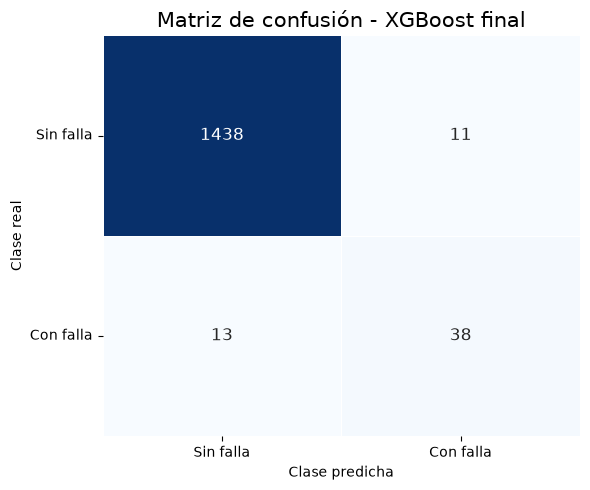

In [71]:
# ==========================================================
# 11.2 Matriz de confusión final
# ==========================================================

cm_test = confusion_matrix(y_test, y_pred_test)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_test,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    linewidths=0.5,
    annot_kws={"size": 12}
)

plt.title(
    "Matriz de confusión - XGBoost final",
    fontsize=15
)

plt.xlabel("Clase predicha")
plt.ylabel("Clase real")

plt.xticks(
    [0.5, 1.5],
    ["Sin falla", "Con falla"]
)

plt.yticks(
    [0.5, 1.5],
    ["Sin falla", "Con falla"],
    rotation=0
)

plt.tight_layout()
plt.show()

**Qué vemos**

La matriz de confusión muestra que el modelo clasificó correctamente 1.438 máquinas sin falla y 38 máquinas con falla. Se registraron 11 falsos positivos y 13 falsos negativos.

Los 13 falsos negativos representan las fallas que no fueron detectadas por el modelo y constituyen el principal tipo de error a considerar en una aplicación de mantenimiento predictivo. Al mismo tiempo, la cantidad de falsos positivos se mantiene relativamente baja, lo que permite reducir el número de alertas innecesarias.

### 11.3 Curva ROC final

La curva ROC final permite evaluar la capacidad de discriminación del XGBoost optimizado sobre el conjunto de prueba. A diferencia de las curvas utilizadas durante la selección de modelos, esta evaluación se realiza una sola vez sobre datos no utilizados previamente para tomar decisiones.

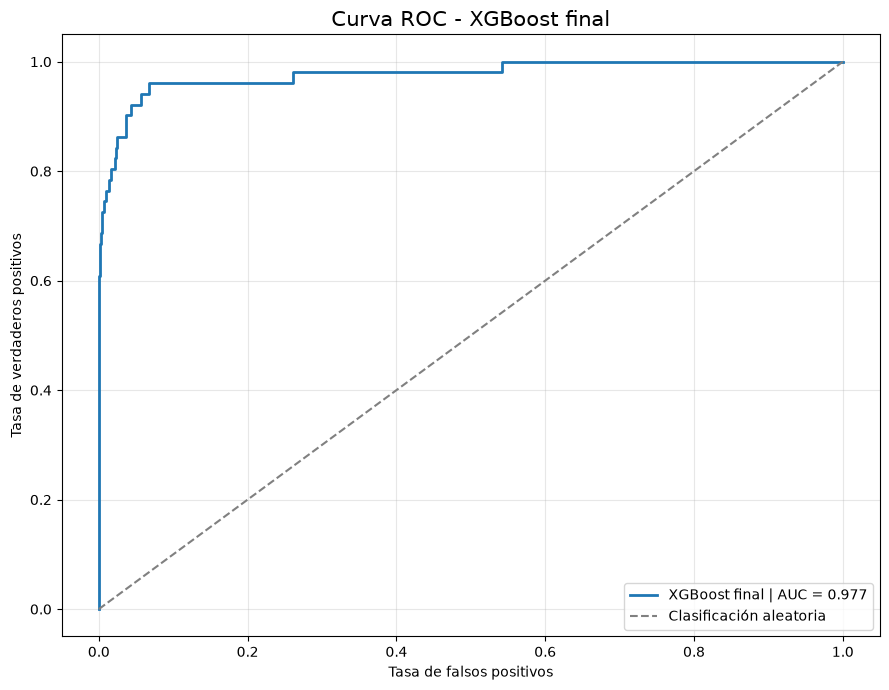

AUC-ROC final sobre el conjunto de prueba: 0.9770


In [72]:
# ==========================================================
# 11.3 Curva ROC final
# ==========================================================

from sklearn.metrics import roc_curve, roc_auc_score

# Calcular puntos de la curva ROC sobre el conjunto de prueba
fpr_test, tpr_test, _ = roc_curve(
    y_test,
    y_proba_test
)

auc_test = roc_auc_score(
    y_test,
    y_proba_test
)

plt.figure(figsize=(9, 7))

# Curva ROC del modelo final
plt.plot(
    fpr_test,
    tpr_test,
    linewidth=2,
    label=f"XGBoost final | AUC = {auc_test:.3f}"
)

# Línea de referencia: clasificación aleatoria
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="gray",
    label="Clasificación aleatoria"
)

plt.title(
    "Curva ROC - XGBoost final",
    fontsize=15
)

plt.xlabel("Tasa de falsos positivos")
plt.ylabel("Tasa de verdaderos positivos")

plt.legend(
    loc="lower right"
)

plt.grid(
    alpha=0.3
)

plt.tight_layout()
plt.show()

print(f"AUC-ROC final sobre el conjunto de prueba: {auc_test:.4f}")

**Qué vemos**

El modelo XGBoost final obtiene un AUC-ROC de 0.9770 sobre el conjunto de prueba, lo que indica una alta capacidad para distinguir entre máquinas con y sin falla. La curva se mantiene claramente por encima de la línea correspondiente a una clasificación aleatoria, mostrando un buen comportamiento discriminativo incluso al evaluar sobre datos que no participaron en la selección ni optimización del modelo.

## 12. Conclusiones

El proyecto permitió desarrollar un flujo completo de Machine Learning para la predicción de fallas en maquinaria utilizando el dataset AI4I 2020. Se realizó el análisis exploratorio de los datos, tratamiento y escalamiento de las variables, comparación de modelos de Machine Learning y Deep Learning, evaluación de distintas estrategias de balanceo y optimización de hiperparámetros.

La experimentación se estructuró en conjuntos de entrenamiento, validación y prueba, manteniendo el conjunto de prueba reservado para la evaluación final. La comparación inicial de seis alternativas mostró diferencias importantes entre los modelos. XGBoost presentó el mejor equilibrio general sobre validación, mientras que algunas arquitecturas MLP alcanzaron mayores niveles de Recall, pero con una Precision considerablemente menor.

En cuanto al desbalance de clases, se compararon un escenario sin balanceo y tres estrategias de tratamiento: Undersampling, Random Oversampling y SMOTE. Random Oversampling obtuvo el mejor equilibrio sobre el conjunto de validación, alcanzando un F1-Score de 0.7400 y un AUC-ROC de 0.9835. Por esta razón, se utilizó como estrategia de balanceo para la etapa posterior de optimización de XGBoost.

Posteriormente, mediante GridSearchCV con validación cruzada estratificada de cinco particiones, se ajustaron los hiperparámetros de XGBoost utilizando únicamente el conjunto de entrenamiento. La configuración seleccionada utilizó 300 estimadores, profundidad máxima de 7, learning rate de 0.1, subsample de 0.8 y colsample_bytree de 1.0. Sobre el conjunto de validación, esta configuración alcanzó un F1-Score de 0.7451 y un AUC-ROC de 0.9847.

La evaluación final sobre el conjunto de prueba mostró un desempeño sólido del modelo seleccionado: Accuracy de 0.9840, Precision de 0.7755, Recall de 0.7451, F1-Score de 0.7600 y AUC-ROC de 0.9770. La matriz de confusión mostró 1.438 verdaderos negativos, 38 verdaderos positivos, 11 falsos positivos y 13 falsos negativos. Estos últimos representan el principal aspecto a vigilar, ya que corresponden a fallas que el modelo no logró detectar.

La curva ROC final confirma una elevada capacidad de discriminación entre las clases, con un AUC-ROC de 0.977, manteniéndose claramente por encima de la clasificación aleatoria.

Finalmente, el análisis SHAP permitió incorporar interpretabilidad al modelo. A nivel global, Torque_Nm, Tool_wear_min y Rotational_speed_rpm fueron las variables con mayor influencia en las predicciones, mientras que Type_L y Type_M presentaron una contribución considerablemente menor. Los casos particulares también mostraron que la influencia de una variable puede cambiar de dirección dependiendo de la combinación de valores de cada observación.

En términos generales, los resultados muestran que XGBoost constituye una alternativa adecuada para apoyar la detección de fallas en este contexto, combinando un buen desempeño predictivo con capacidad de interpretación. Sin embargo, el modelo trabaja con observaciones puntuales y no incorpora explícitamente la evolución temporal de las variables, por lo que existe espacio para futuras mejoras orientadas a incorporar información secuencial y reducir los casos de fallas no detectadas.